In [35]:
import sys
sys.path.insert(0, '..')

import json, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'gpqa_full_sim_tier3'

W_COLORS = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
W_VALUES = [1, 2, 5]
DS_COLORS = {'gpqa': '#4C72B0', 'hiddenbench': '#C44E52'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [36]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_qid = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        if qid not in by_qid or str(f) > by_qid[qid]['_path']:
            d['_path'] = str(f)
            by_qid[qid] = d
    return by_qid

raw = {w: load_window_data(w) for w in W_VALUES}

for w, data in raw.items():
    print(f'W={w}: {len(data)} questions — qids: {sorted(data.keys())}')

common_qids = sorted(
    set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys())
)
print(f'\nCommon across all W: {len(common_qids)} — {common_qids}')

W=1: 13 questions — qids: ['14', '146', '15', '159', '194', '28', '34', '43', '46', '47', '57', '95', '98']
W=2: 12 questions — qids: ['14', '146', '15', '159', '28', '34', '43', '46', '47', '57', '95', '98']
W=5: 12 questions — qids: ['14', '146', '15', '159', '28', '34', '43', '46', '47', '57', '95', '98']

Common across all W: 12 — ['14', '146', '15', '159', '28', '34', '43', '46', '47', '57', '95', '98']


## Helper Functions

In [37]:
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

def confidences_at(rep, t):
    return [a.get('confidence') for a in rep['trajectory'][t]['phase_b']]

def tokens_at(rep, t):
    return [
        (a.get('prompt_tokens', 0), a.get('completion_tokens', 0))
        for a in rep['trajectory'][t]['phase_b']
    ]

def count_flips(rep):
    traj = rep['trajectory']
    total = 0
    for ag in range(len(traj[0]['phase_b'])):
        for t in range(1, len(traj)):
            if traj[t-1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']:
                total += 1
    return total

def rep_stats(rep, gt):
    traj = rep['trajectory']
    T = len(traj)
    v0 = votes_at(rep, 0)
    vf = votes_at(rep, T - 1)
    majority = max(set(vf), key=vf.count)
    conf0 = [c for c in confidences_at(rep, 0) if c is not None]
    conff = [c for c in confidences_at(rep, T - 1) if c is not None]
    all_pt = sum(pt for t in range(T) for pt, _ in tokens_at(rep, t))
    all_ct = sum(ct for t in range(T) for _, ct in tokens_at(rep, t))
    flips = count_flips(rep)
    return {
        'T': T,
        'flips': flips,
        'converged': len(set(vf)) == 1,
        'correct': majority == gt,
        'initial_acc': sum(v == gt for v in v0) / len(v0),
        'final_acc': sum(v == gt for v in vf) / len(vf),
        'mean_conf_0': np.mean(conf0) if conf0 else np.nan,
        'mean_conf_f': np.mean(conff) if conff else np.nan,
        'never_converged': T == rep.get('T', 15) and len(set(vf)) > 1,
        'total_prompt_tokens': all_pt,
        'total_completion_tokens': all_ct,
        'tokens_per_flip': (all_pt + all_ct) / max(flips, 1),
    }

def question_stats(d):
    gt = d['ground_truth']
    stats = [rep_stats(r, gt) for r in d['repetitions']]
    return {
        'qid': d['question_id'],
        'dataset': d.get('dataset', 'unknown'),
        'W': d['W'],
        'N': d['N'],
        'T_max': d['T'],
        'n_reps': len(stats),
        'accuracy': np.mean([s['correct'] for s in stats]),
        'initial_acc': np.mean([s['initial_acc'] for s in stats]),
        'mean_T': np.mean([s['T'] for s in stats]),
        'mean_flips': np.mean([s['flips'] for s in stats]),
        'convergence_rate': np.mean([s['converged'] for s in stats]),
        'never_converged_rate': np.mean([s['never_converged'] for s in stats]),
        'mean_conf_0': np.nanmean([s['mean_conf_0'] for s in stats]),
        'mean_conf_f': np.nanmean([s['mean_conf_f'] for s in stats]),
        'acc_delta': np.mean([s['final_acc'] - s['initial_acc'] for s in stats]),
        'mean_prompt_tokens': np.mean([s['total_prompt_tokens'] for s in stats]),
        'mean_completion_tokens': np.mean([s['total_completion_tokens'] for s in stats]),
        'mean_total_tokens': np.mean([s['total_prompt_tokens'] + s['total_completion_tokens'] for s in stats]),
        'mean_tokens_per_flip': np.mean([s['tokens_per_flip'] for s in stats]),
    }

records = []
for w, data in raw.items():
    for qid, d in data.items():
        records.append(question_stats(d))

df = pd.DataFrame(records)
dc = df[df['qid'].isin(common_qids)].copy()

print(f'Total rows: {len(df)}  |  Common-qid rows: {len(dc)}')
display(dc.head(37))

Total rows: 37  |  Common-qid rows: 36


,qid,dataset,W,N,T_max,n_reps,accuracy,initial_acc,mean_T,mean_flips,convergence_rate,never_converged_rate,mean_conf_0,mean_conf_f,acc_delta,mean_prompt_tokens,mean_completion_tokens,mean_total_tokens,mean_tokens_per_flip
0,98,gpqa,1,4,15,50,0.28,0.145,5.08,2.98,1.00,0.0,7.050,9.125,0.135,54757.36,7226.12,61983.48,27011.038167
1,159,gpqa,1,4,15,50,0.42,0.150,4.62,2.90,1.00,0.0,7.780,9.465,0.270,43001.48,5517.86,48519.34,20242.225286
3,47,gpqa,1,4,15,50,0.22,0.385,5.52,4.64,1.00,0.0,6.910,9.380,-0.165,49349.08,7064.92,56414.00,14656.324640
4,95,gpqa,1,4,15,50,0.32,0.285,5.32,3.38,1.00,0.0,6.970,8.960,0.035,55885.78,9127.04,65012.82,22864.698143
5,146,gpqa,1,4,15,50,0.92,0.845,4.18,1.30,1.00,0.0,7.305,9.290,0.075,33176.96,6029.04,39206.00,25314.775470
6,14,hiddenbench,1,4,15,50,0.54,0.065,7.72,7.42,0.98,0.0,7.445,9.040,0.485,74076.64,8607.08,82683.72,12041.471318
7,28,hiddenbench,1,4,15,50,0.42,0.180,6.36,4.08,0.98,0.0,7.370,8.995,0.240,55085.26,7232.50,62317.76,17614.789905
8,43,hiddenbench,1,4,15,50,0.42,0.165,6.44,4.92,1.00,0.0,7.240,9.000,0.255,60068.34,7613.46,67681.80,17454.550551
9,46,hiddenbench,1,4,15,50,0.46,0.190,6.72,5.00,0.98,0.0,7.010,8.900,0.265,67702.10,7652.20,75354.30,17155.663256
10,57,hiddenbench,1,4,15,50,0.30,0.075,8.38,6.20,0.94,0.0,7.325,9.030,0.225,85483.44,10131.34,95614.78,16275.966593


## Summary by W (common questions)

In [38]:
summary = dc.groupby('W').agg(
    n_questions=('qid', 'count'),
    accuracy=('accuracy', 'mean'),
    initial_acc=('initial_acc', 'mean'),
    acc_delta=('acc_delta', 'mean'),
    mean_T=('mean_T', 'mean'),
    mean_flips=('mean_flips', 'mean'),
    convergence_rate=('convergence_rate', 'mean'),
    never_converged_rate=('never_converged_rate', 'mean'),
    mean_conf_0=('mean_conf_0', 'mean'),
    mean_conf_f=('mean_conf_f', 'mean'),
    mean_prompt_tokens=('mean_prompt_tokens', 'mean'),
    mean_completion_tokens=('mean_completion_tokens', 'mean'),
    mean_total_tokens=('mean_total_tokens', 'mean'),
).round(3)

display(summary)

,n_questions,accuracy,initial_acc,acc_delta,mean_T,mean_flips,convergence_rate,never_converged_rate,mean_conf_0,mean_conf_f,mean_prompt_tokens,mean_completion_tokens,mean_total_tokens
W,,,,,,,,,,,,,
1,12,0.420,0.256,0.167,6.413,4.245,0.968,0.0,7.222,9.071,62828.730,8147.605,70976.335
2,12,0.417,0.267,0.153,5.805,3.632,0.985,0.0,7.200,8.981,73533.263,7472.493,81005.757
5,12,0.398,0.242,0.159,6.197,3.915,0.962,0.0,7.244,8.865,112980.312,7975.468,120955.780


## Overview Bar Plot

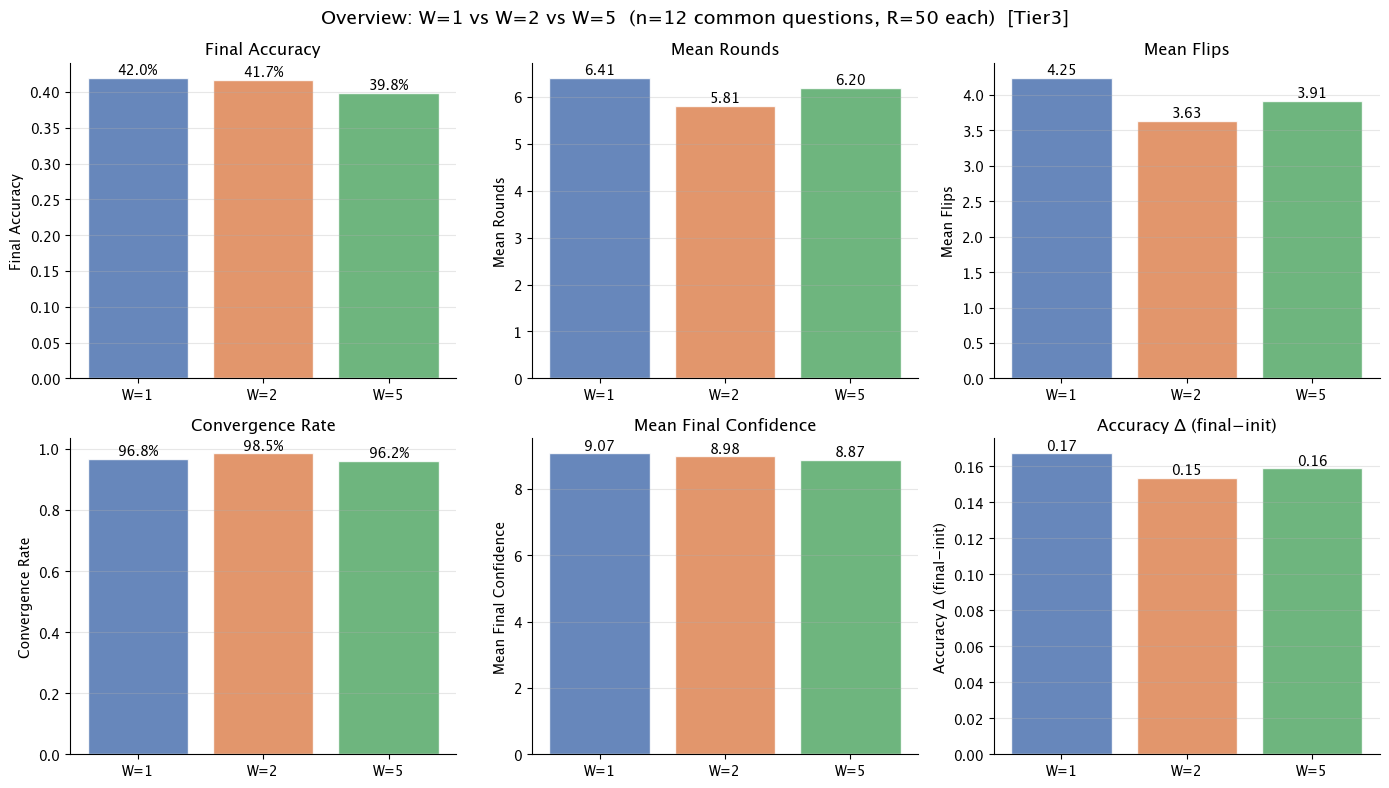

In [39]:
metrics = [
    ('accuracy',          'Final Accuracy',          True),
    ('mean_T',            'Mean Rounds',             False),
    ('mean_flips',        'Mean Flips',              False),
    ('convergence_rate',  'Convergence Rate',        True),
    ('mean_conf_f',       'Mean Final Confidence',   False),
    ('acc_delta',         'Accuracy Δ (final−init)', False),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (col, label, pct) in zip(axes.flat, metrics):
    vals = [dc[dc['W'] == w][col].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        txt = f'{v:.1%}' if pct else f'{v:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003 * max(vals),
                txt, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

n_ds = dc['qid'].nunique()
fig.suptitle(f'Overview: W=1 vs W=2 vs W=5  (n={n_ds} common questions, R=50 each)  [Tier3]',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Per-Dataset Accuracy (gpqa vs hiddenbench)

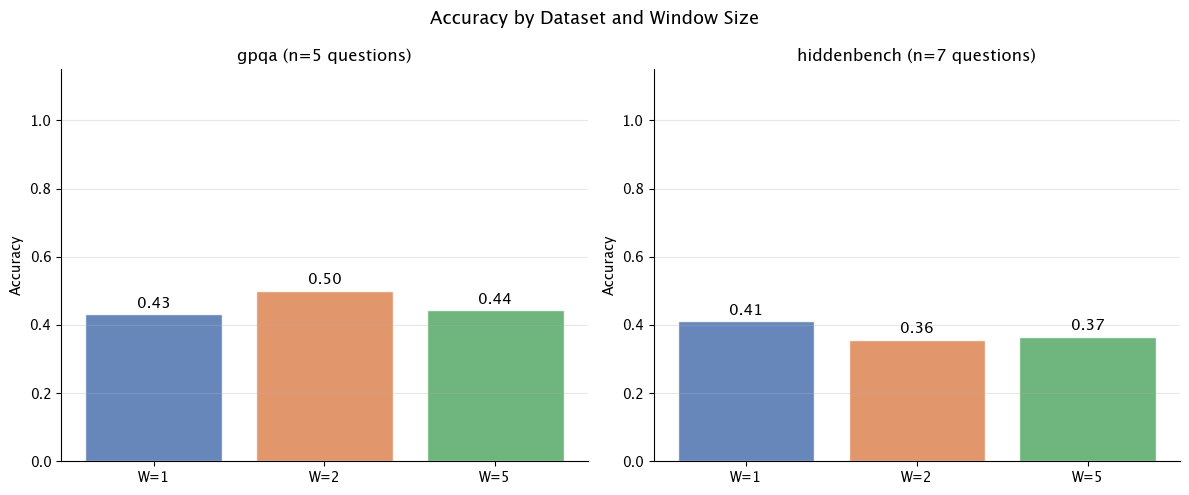

Accuracy by dataset × W:


W,1,2,5
dataset,,,
gpqa,0.432,0.500,0.444
hiddenbench,0.411,0.357,0.366


In [40]:
datasets = dc['dataset'].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), squeeze=False)

for ax, ds in zip(axes[0], datasets):
    sub = dc[dc['dataset'] == ds]
    vals = [sub[sub['W'] == w]['accuracy'].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    n_q = sub['qid'].nunique()
    ax.set_title(f'{ds} (n={n_q} questions)', fontsize=12)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Accuracy by Dataset and Window Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Accuracy by dataset × W:')
display(dc.groupby(['dataset', 'W'])['accuracy'].mean().unstack('W').round(3))

## Per-Question Accuracy Comparison

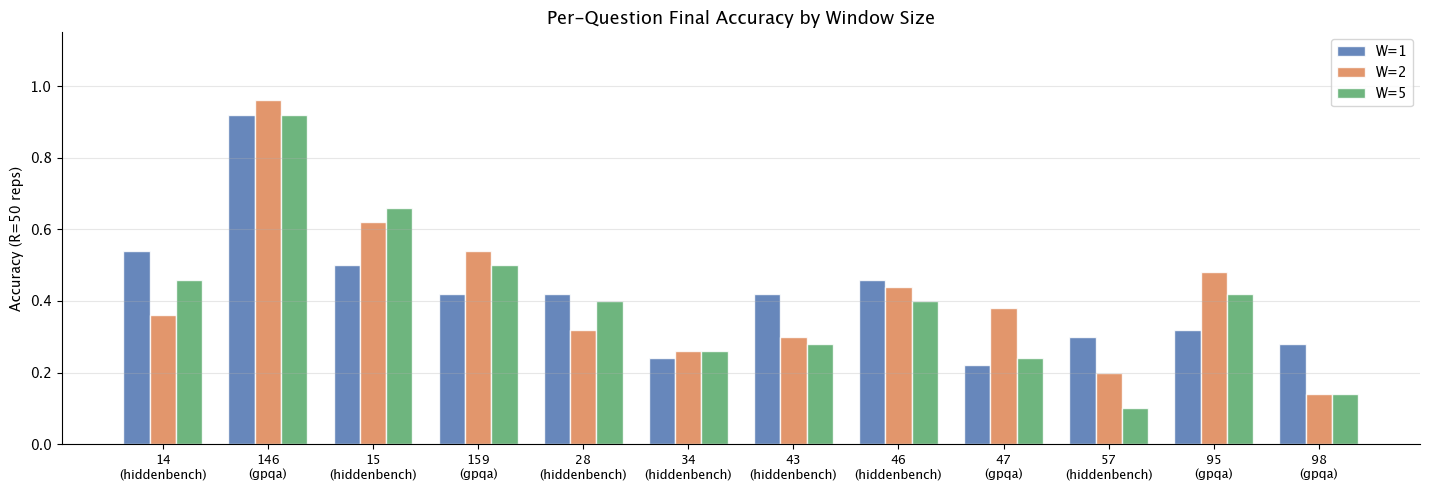

W,1,2,5
qid,,,
14,0.54,0.36,0.46
146,0.92,0.96,0.92
15,0.50,0.62,0.66
159,0.42,0.54,0.50
28,0.42,0.32,0.40
34,0.24,0.26,0.26
43,0.42,0.30,0.28
46,0.46,0.44,0.40
47,0.22,0.38,0.24


In [41]:
pivot_acc = dc.pivot(index='qid', columns='W', values='accuracy')
qid_ds = dc[['qid', 'dataset']].drop_duplicates().set_index('qid')['dataset']

fig, ax = plt.subplots(figsize=(max(12, len(common_qids) * 1.2), 5))
x = np.arange(len(common_qids))
w_bar = 0.25

for i, w in enumerate(W_VALUES):
    vals = [pivot_acc.loc[qid, w] for qid in common_qids]
    ax.bar(x + (i - 1) * w_bar, vals, w_bar,
           label=f'W={w}', color=W_COLORS[w], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
xlabels = [f'{qid}\n({qid_ds.get(qid, "?")})' for qid in common_qids]
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Accuracy (R=50 reps)')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Question Final Accuracy by Window Size', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

display(pivot_acc.round(2))

## Accuracy Heatmap

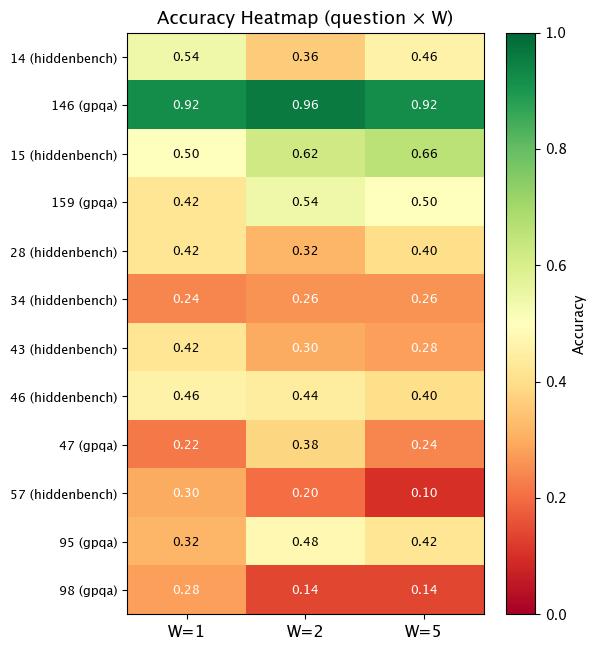

In [42]:
heat = dc.pivot(index='qid', columns='W', values='accuracy')
heat.columns = [f'W={w}' for w in heat.columns]

fig, ax = plt.subplots(figsize=(6, max(3, len(common_qids) * 0.55)))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Accuracy')

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=12)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([
    f'{qid} ({qid_ds.get(qid, "?")})' for qid in heat.index
], fontsize=9)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='black' if 0.3 < v < 0.7 else 'white')

ax.set_title('Accuracy Heatmap (question × W)', fontsize=13)
plt.tight_layout()
plt.show()

## Trajectory Length & Flips

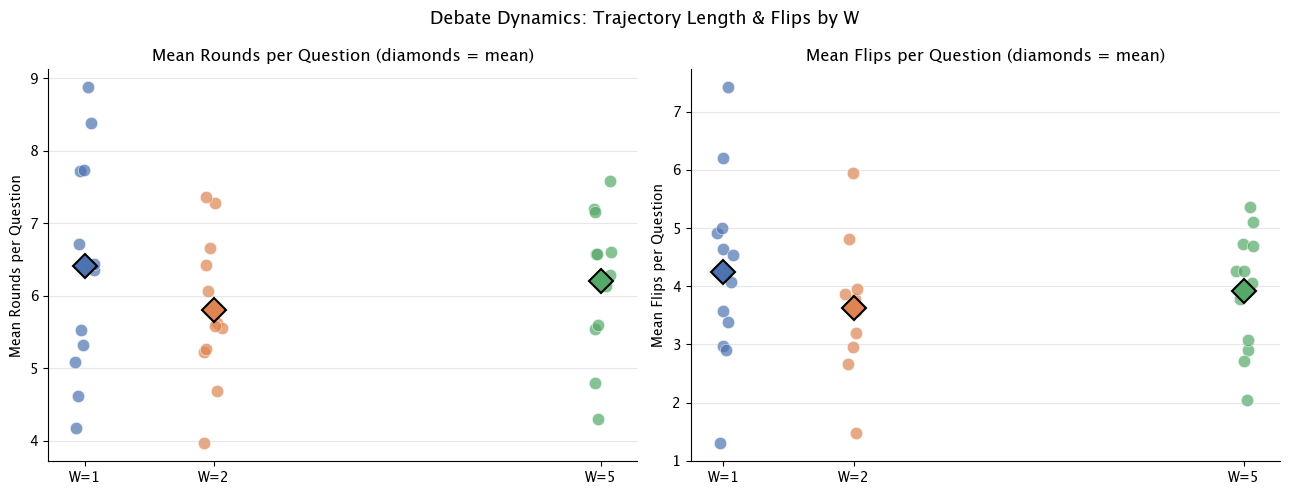

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], 'mean_T',     'Mean Rounds per Question'),
    (axes[1], 'mean_flips', 'Mean Flips per Question'),
]:
    for w in W_VALUES:
        vals = dc[dc['W'] == w][col].values
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter([w + j for j in jitter], vals,
                   color=W_COLORS[w], alpha=0.7, s=80, edgecolors='white',
                   linewidths=0.5, label=f'W={w}')
        ax.plot(w, np.mean(vals), 'D', color=W_COLORS[w], markersize=12,
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)

    ax.set_xticks(W_VALUES)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_ylabel(label)
    ax.set_title(f'{label} (diamonds = mean)', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Debate Dynamics: Trajectory Length & Flips by W', fontsize=13)
plt.tight_layout()
plt.show()

## Round-by-Round Accuracy Trajectory

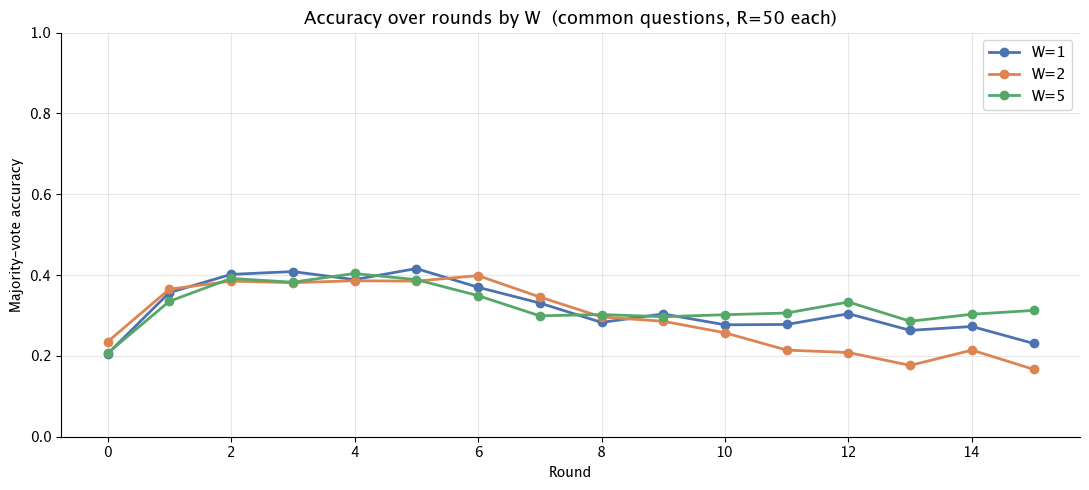

In [44]:
def acc_trajectory(data, qids):
    T_max = max(len(rep['trajectory']) for d in data.values() for rep in d['repetitions'])
    acc_by_round = {t: [] for t in range(T_max)}
    for qid in qids:
        if qid not in data:
            continue
        d = data[qid]
        gt = d['ground_truth']
        for rep in d['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                votes = [a['vote'] for a in rnd['phase_b']]
                majority = max(set(votes), key=votes.count)
                acc_by_round[t].append(majority == gt)
    rounds, means = [], []
    for t in range(T_max):
        if acc_by_round[t]:
            rounds.append(t)
            means.append(np.mean(acc_by_round[t]))
    return rounds, means

fig, ax = plt.subplots(figsize=(11, 5))

for w in W_VALUES:
    rounds, means = acc_trajectory(raw[w], common_qids)
    ax.plot(rounds, means, marker='o', label=f'W={w}', color=W_COLORS[w], linewidth=2, markersize=6)

ax.set_xlabel('Round')
ax.set_ylabel('Majority-vote accuracy')
ax.set_title('Accuracy over rounds by W  (common questions, R=50 each)', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Confidence Trajectory over Rounds

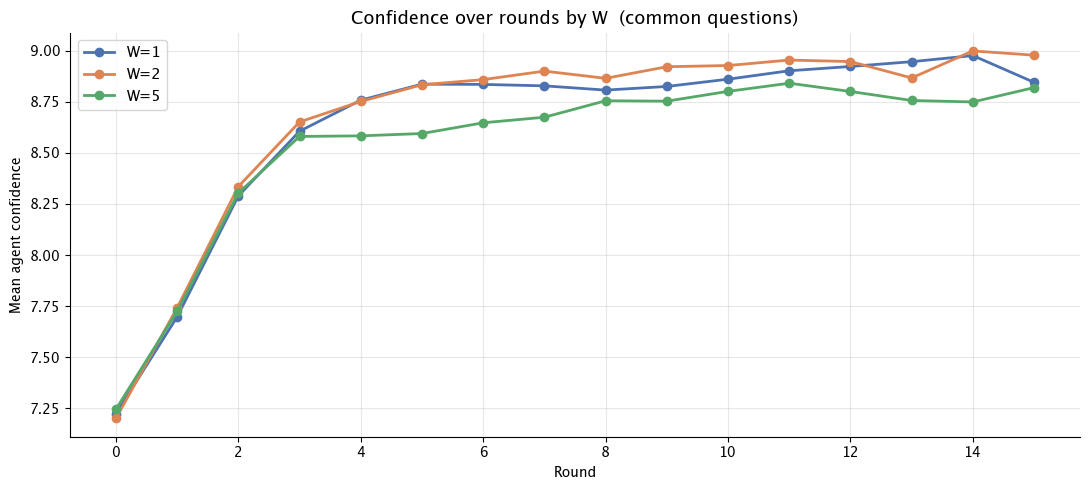

In [45]:
def confidence_trajectory(data, qids):
    T_max = max(len(rep['trajectory']) for d in data.values() for rep in d['repetitions'])
    conf_by_round = {t: [] for t in range(T_max)}
    for qid in qids:
        if qid not in data:
            continue
        for rep in data[qid]['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                confs = [a.get('confidence') for a in rnd['phase_b'] if a.get('confidence') is not None]
                conf_by_round[t].extend(confs)
    rounds, means = [], []
    for t in range(T_max):
        if conf_by_round[t]:
            rounds.append(t)
            means.append(np.mean(conf_by_round[t]))
    return rounds, means

fig, ax = plt.subplots(figsize=(11, 5))

for w in W_VALUES:
    rounds, means = confidence_trajectory(raw[w], common_qids)
    ax.plot(rounds, means, marker='o', label=f'W={w}', color=W_COLORS[w], linewidth=2, markersize=6)

ax.set_xlabel('Round')
ax.set_ylabel('Mean agent confidence')
ax.set_title('Confidence over rounds by W  (common questions)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Confidence vs Flips

Agent-round observations (common qids): 44196
With confidence: 44196
Flip rate: 0.160

Mean confidence: flipped vs stayed
flipped
stayed     8.344253
flipped    7.740919
Name: confidence, dtype: float64


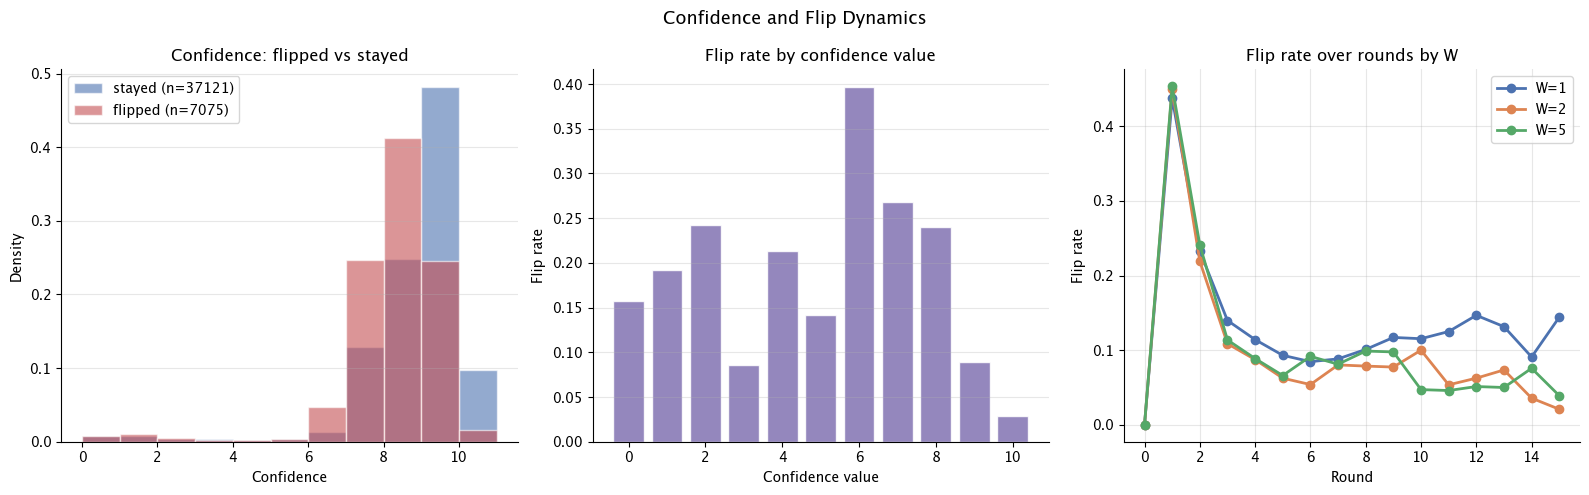

In [46]:
conf_flip_records = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        gt = d['ground_truth']
        for rep in d['repetitions']:
            traj = rep['trajectory']
            for ag in range(len(traj[0]['phase_b'])):
                for t in range(len(traj)):
                    a = traj[t]['phase_b'][ag]
                    did_flip = (
                        t > 0 and traj[t-1]['phase_b'][ag]['vote'] != a['vote']
                    )
                    conf_flip_records.append({
                        'W': w,
                        'qid': qid,
                        'round': t,
                        'confidence': a.get('confidence'),
                        'flipped': did_flip,
                        'correct': a['vote'] == gt,
                        'prompt_tokens': a.get('prompt_tokens', 0),
                        'completion_tokens': a.get('completion_tokens', 0),
                    })

cf = pd.DataFrame(conf_flip_records)
cf_conf = cf[cf['confidence'].notna()].copy()

print(f'Agent-round observations (common qids): {len(cf)}')
print(f'With confidence: {len(cf_conf)}')
print(f'Flip rate: {cf["flipped"].mean():.3f}')
print()
print('Mean confidence: flipped vs stayed')
print(cf_conf.groupby('flipped')['confidence'].mean().rename({False: 'stayed', True: 'flipped'}))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for flipped, label, color in [(False, 'stayed', '#4C72B0'), (True, 'flipped', '#C44E52')]:
    sub = cf_conf[cf_conf['flipped'] == flipped]['confidence']
    ax.hist(sub, bins=range(0, 12), alpha=0.6, color=color, label=f'{label} (n={len(sub)})',
            density=True, edgecolor='white')
ax.set_xlabel('Confidence')
ax.set_ylabel('Density')
ax.set_title('Confidence: flipped vs stayed', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
flip_by_conf = cf_conf.groupby('confidence')['flipped'].mean()
ax.bar(flip_by_conf.index, flip_by_conf.values, color='#8172B2', alpha=0.85, edgecolor='white')
ax.set_xlabel('Confidence value')
ax.set_ylabel('Flip rate')
ax.set_title('Flip rate by confidence value', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[2]
for w in W_VALUES:
    sub = cf_conf[cf_conf['W'] == w]
    flip_by_round = sub.groupby('round')['flipped'].mean()
    ax.plot(flip_by_round.index, flip_by_round.values, marker='o',
            label=f'W={w}', color=W_COLORS[w], linewidth=2, markersize=6)
ax.set_xlabel('Round')
ax.set_ylabel('Flip rate')
ax.set_title('Flip rate over rounds by W', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Confidence and Flip Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Confidence Calibration (confidence vs accuracy)

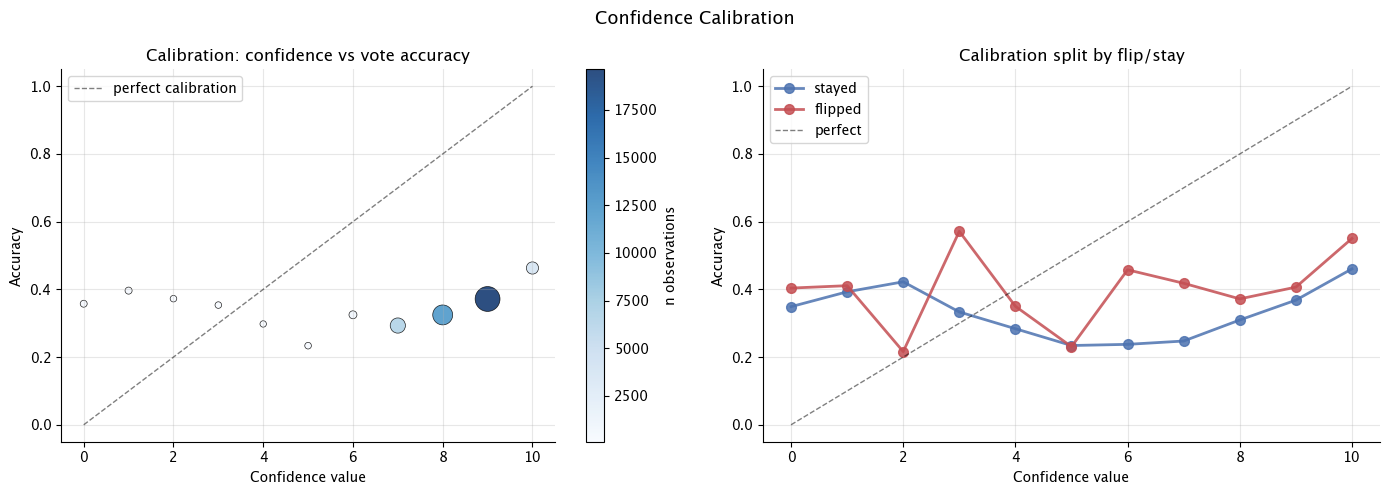

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cal = cf_conf.groupby('confidence')['correct'].agg(['mean', 'count']).reset_index()
sc = ax.scatter(cal['confidence'], cal['mean'], s=cal['count'] / cal['count'].max() * 300 + 20,
                c=cal['count'], cmap='Blues', edgecolors='black', linewidths=0.5, alpha=0.85)
plt.colorbar(sc, ax=ax, label='n observations')
ax.plot([0, 10], [0, 1], 'k--', linewidth=1, alpha=0.5, label='perfect calibration')
ax.set_xlabel('Confidence value')
ax.set_ylabel('Accuracy')
ax.set_title('Calibration: confidence vs vote accuracy', fontsize=12)
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
for flipped, label, color in [(False, 'stayed', '#4C72B0'), (True, 'flipped', '#C44E52')]:
    sub = cf_conf[cf_conf['flipped'] == flipped]
    if len(sub) == 0:
        continue
    cal_sub = sub.groupby('confidence')['correct'].mean()
    ax.plot(cal_sub.index, cal_sub.values, marker='o', label=label,
            color=color, linewidth=2, markersize=7, alpha=0.85)
ax.plot([0, 10], [0, 1], 'k--', linewidth=1, alpha=0.5, label='perfect')
ax.set_xlabel('Confidence value')
ax.set_ylabel('Accuracy')
ax.set_title('Calibration split by flip/stay', fontsize=12)
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Confidence Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Token Usage

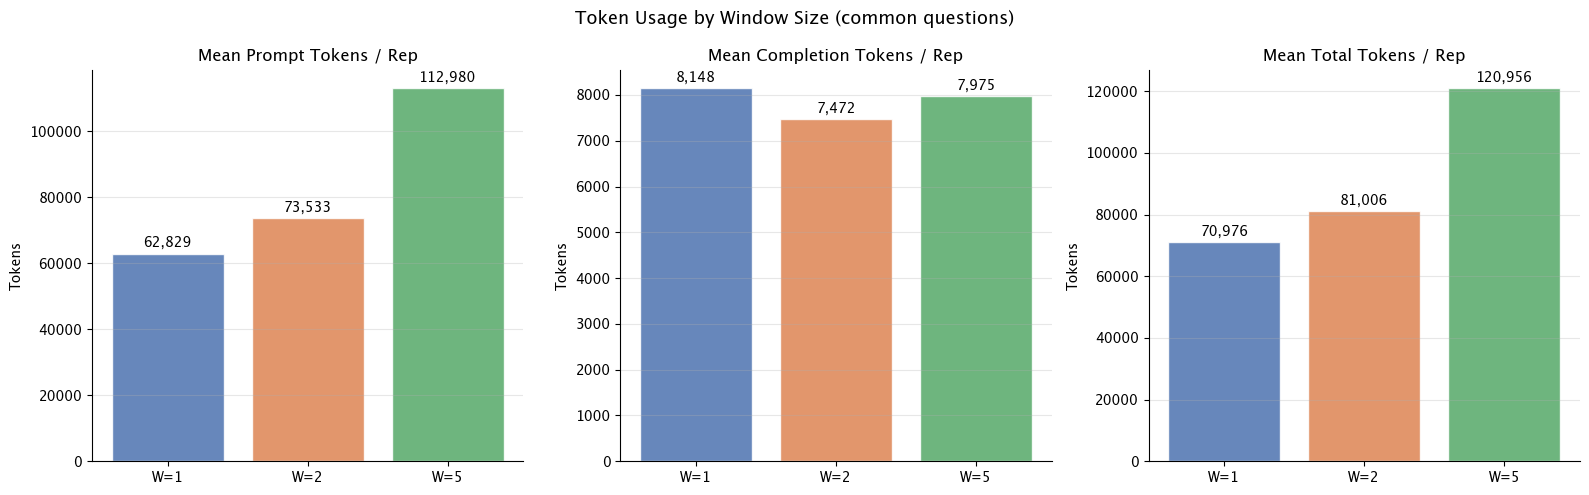

Token summary by W:


,mean_prompt_tokens,mean_completion_tokens,mean_total_tokens
W,,,
1,62829.0,8148.0,70976.0
2,73533.0,7472.0,81006.0
5,112980.0,7975.0,120956.0


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in [
    (axes[0], 'mean_prompt_tokens',     'Mean Prompt Tokens / Rep'),
    (axes[1], 'mean_completion_tokens', 'Mean Completion Tokens / Rep'),
    (axes[2], 'mean_total_tokens',      'Mean Total Tokens / Rep'),
]:
    vals = [dc[dc['W'] == w][col].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.01,
                f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('Tokens')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Token Usage by Window Size (common questions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Token summary by W:')
display(dc.groupby('W')[['mean_prompt_tokens', 'mean_completion_tokens', 'mean_total_tokens']].mean().round(0))

## Tokens per Round

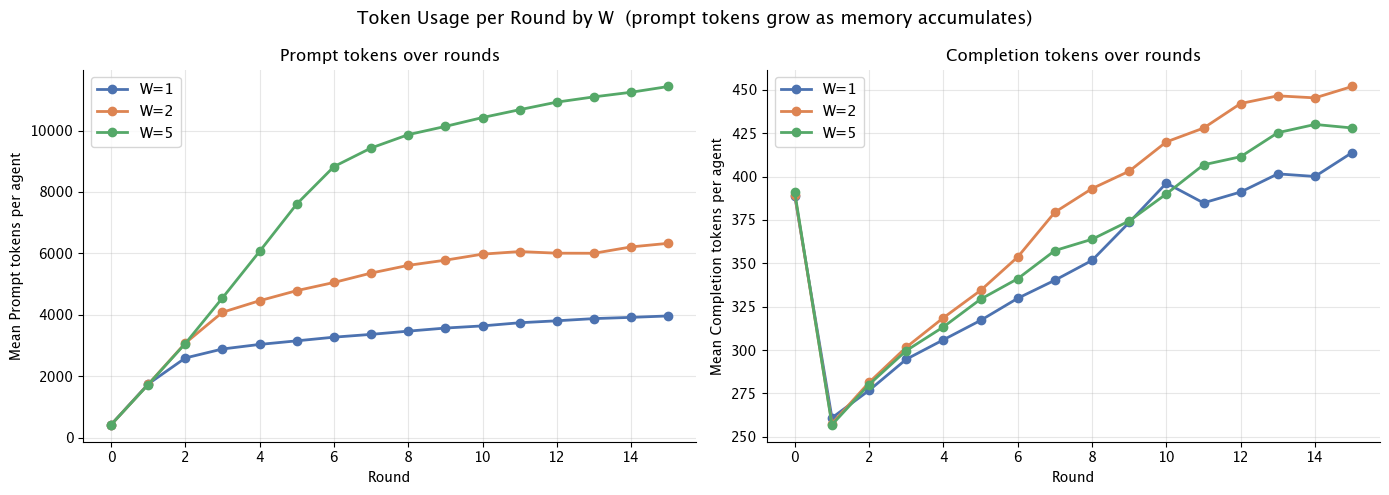

In [49]:
def token_trajectory(data, qids):
    T_max = max(len(rep['trajectory']) for d in data.values() for rep in d['repetitions'])
    pt_by_round = {t: [] for t in range(T_max)}
    ct_by_round = {t: [] for t in range(T_max)}
    for qid in qids:
        if qid not in data:
            continue
        for rep in data[qid]['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                for a in rnd['phase_b']:
                    pt_by_round[t].append(a.get('prompt_tokens', 0))
                    ct_by_round[t].append(a.get('completion_tokens', 0))
    rounds, pt_means, ct_means = [], [], []
    for t in range(T_max):
        if pt_by_round[t]:
            rounds.append(t)
            pt_means.append(np.mean(pt_by_round[t]))
            ct_means.append(np.mean(ct_by_round[t]))
    return rounds, pt_means, ct_means

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, label in [(axes[0], 0, 'Prompt'), (axes[1], 1, 'Completion')]:
    for w in W_VALUES:
        rounds, pt, ct = token_trajectory(raw[w], common_qids)
        vals = pt if idx == 0 else ct
        ax.plot(rounds, vals, marker='o', label=f'W={w}', color=W_COLORS[w], linewidth=2, markersize=6)
    ax.set_xlabel('Round')
    ax.set_ylabel(f'Mean {label} tokens per agent')
    ax.set_title(f'{label} tokens over rounds', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Token Usage per Round by W  (prompt tokens grow as memory accumulates)', fontsize=13)
plt.tight_layout()
plt.show()

## Tokens vs Accuracy & Flips

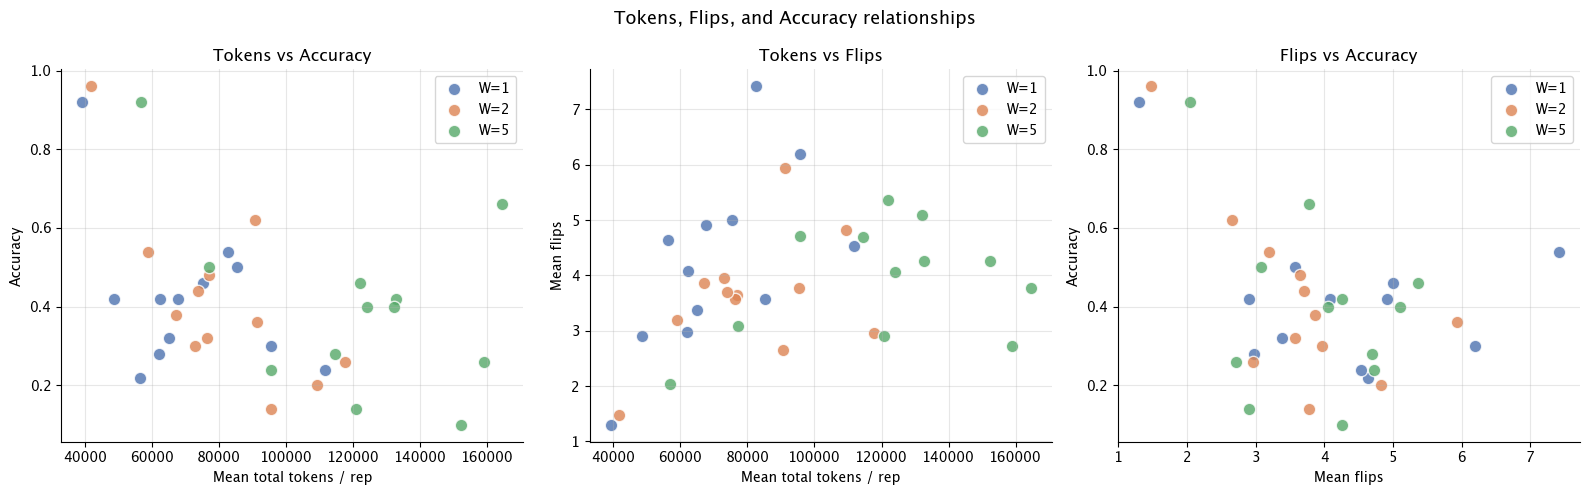

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for w in W_VALUES:
    sub = dc[dc['W'] == w]
    ax.scatter(sub['mean_total_tokens'], sub['accuracy'],
               color=W_COLORS[w], label=f'W={w}', s=80, alpha=0.8, edgecolors='white')
ax.set_xlabel('Mean total tokens / rep')
ax.set_ylabel('Accuracy')
ax.set_title('Tokens vs Accuracy', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
for w in W_VALUES:
    sub = dc[dc['W'] == w]
    ax.scatter(sub['mean_total_tokens'], sub['mean_flips'],
               color=W_COLORS[w], label=f'W={w}', s=80, alpha=0.8, edgecolors='white')
ax.set_xlabel('Mean total tokens / rep')
ax.set_ylabel('Mean flips')
ax.set_title('Tokens vs Flips', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[2]
for w in W_VALUES:
    sub = dc[dc['W'] == w]
    ax.scatter(sub['mean_flips'], sub['accuracy'],
               color=W_COLORS[w], label=f'W={w}', s=80, alpha=0.8, edgecolors='white')
ax.set_xlabel('Mean flips')
ax.set_ylabel('Accuracy')
ax.set_title('Flips vs Accuracy', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Tokens, Flips, and Accuracy relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Convergence

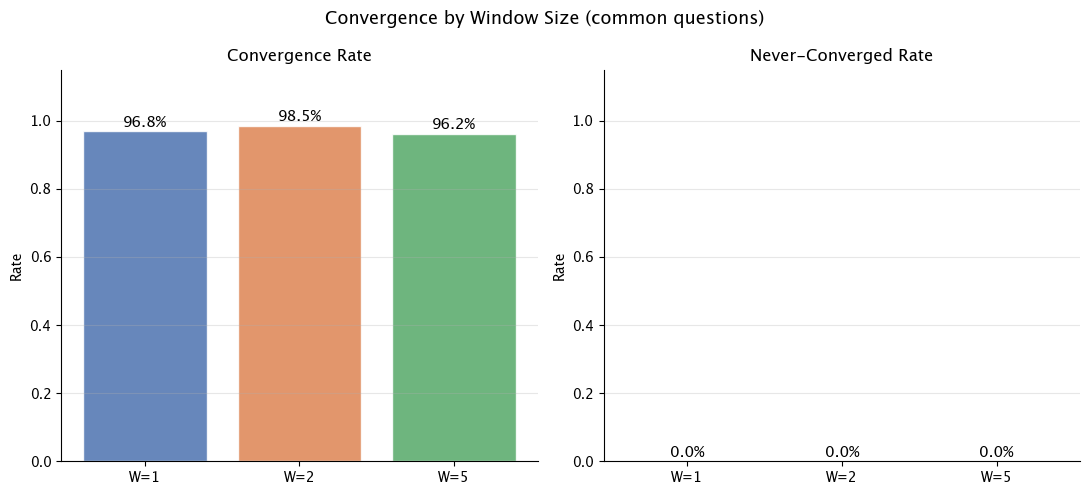

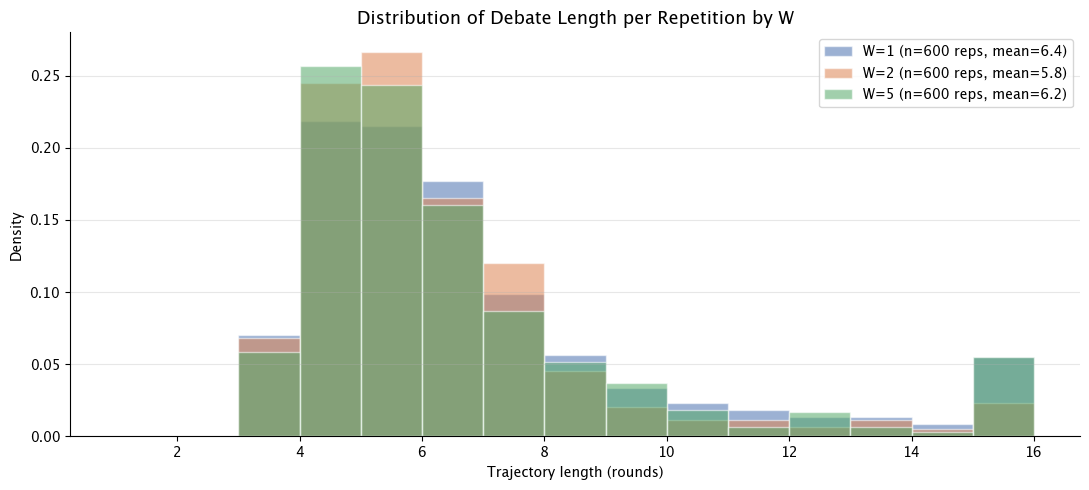

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, label in [
    (axes[0], 'convergence_rate',    'Convergence Rate'),
    (axes[1], 'never_converged_rate','Never-Converged Rate'),
]:
    vals = [dc[dc['W'] == w][col].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Rate')
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Convergence by Window Size (common questions)', fontsize=13)
plt.tight_layout()
plt.show()

def all_rep_T(data, qids):
    lengths = []
    for qid in qids:
        if qid not in data:
            continue
        for rep in data[qid]['repetitions']:
            lengths.append(len(rep['trajectory']))
    return lengths

fig, ax = plt.subplots(figsize=(11, 5))
bins = range(1, 17)

for w in W_VALUES:
    lengths = all_rep_T(raw[w], common_qids)
    ax.hist(lengths, bins=bins, alpha=0.55, color=W_COLORS[w],
            label=f'W={w} (n={len(lengths)} reps, mean={np.mean(lengths):.1f})',
            edgecolor='white', density=True)

ax.set_xlabel('Trajectory length (rounds)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Debate Length per Repetition by W', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Persuasiveness Score

In [52]:
def compute_persuasiveness(rep):
    traj = rep['trajectory']
    T = len(traj)
    N = len(traj[0]['phase_b'])
    scores = {}
    for a in range(N):
        num = 0.0
        denom = 0.0
        for t in range(T - 1):
            phase = traj[t]['phase_b']
            next_phase = traj[t + 1]['phase_b']
            v_a = phase[a]['vote']
            v_a_next = next_phase[a]['vote']
            c_a = phase[a].get('confidence') or 0
            k = sum(1 for ag in range(N) if phase[ag]['vote'] == v_a)
            for b in range(N):
                if b == a:
                    continue
                v_b = phase[b]['vote']
                v_b_next = next_phase[b]['vote']
                c_b = phase[b].get('confidence') or 0
                if v_b != v_a:
                    denom += c_b / k
                    if v_b_next == v_a:
                        num += c_b / k
            if v_a_next != v_a:
                num -= c_a
                denom += c_a
        scores[a] = num / denom if denom > 0 else np.nan
    return scores

pers_records = []
for w, data in raw.items():
    for qid, d in data.items():
        for rep_idx, rep in enumerate(d['repetitions']):
            agent_scores = compute_persuasiveness(rep)
            traj = rep['trajectory']
            for a, score in agent_scores.items():
                pt = sum(traj[t]['phase_b'][a].get('prompt_tokens', 0) for t in range(len(traj)))
                ct = sum(traj[t]['phase_b'][a].get('completion_tokens', 0) for t in range(len(traj)))
                pers_records.append({
                    'W': w, 'qid': qid, 'dataset': d.get('dataset', 'unknown'),
                    'rep': rep_idx, 'agent': a,
                    'persuasiveness': score,
                    'prompt_tokens': pt,
                    'completion_tokens': ct,
                    'total_tokens': pt + ct,
                })

pers_df = pd.DataFrame(pers_records)
pers_common = pers_df[pers_df['qid'].isin(common_qids)]

print(f'Per-agent-per-rep rows (common qids): {len(pers_common)}')
print()
print('Persuasiveness by W:')
display(
    pers_common.groupby('W')['persuasiveness']
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)

pers_q = pers_common.groupby(['W', 'qid'])['persuasiveness'].mean().reset_index()
dc_p = dc.merge(pers_q, on=['W', 'qid'])


Per-agent-per-rep rows (common qids): 7200

Persuasiveness by W:


,mean,std,min,max
W,,,,
1,0.165,0.480,-1.00,1.0
2,0.181,0.500,-0.92,1.0
5,0.181,0.496,-1.00,1.0


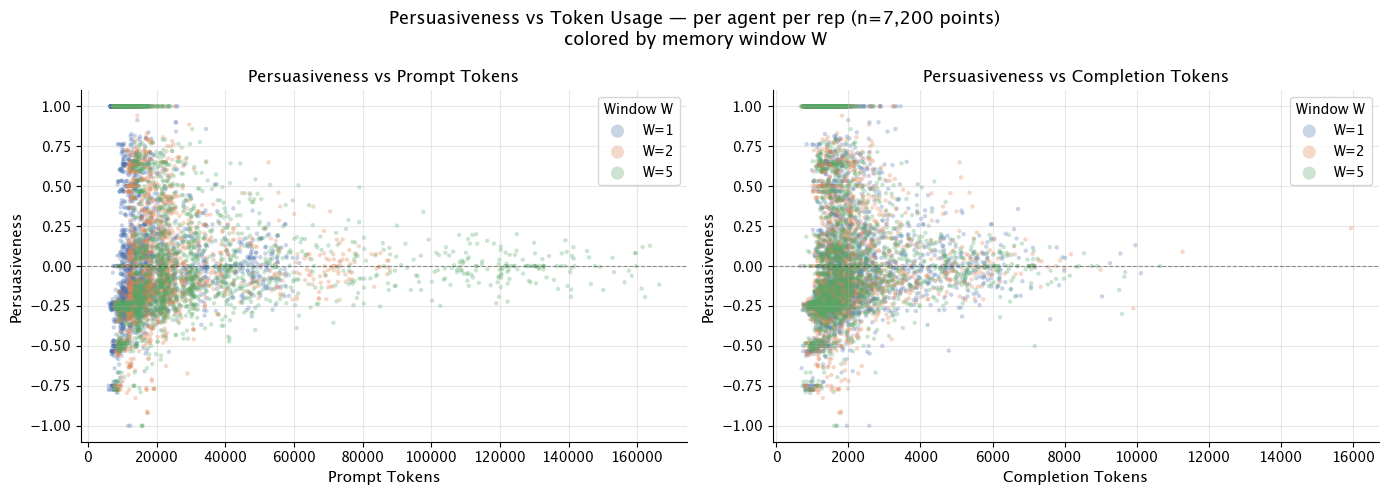

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xcol, xlabel in [
    (axes[0], 'prompt_tokens',     'Prompt Tokens'),
    (axes[1], 'completion_tokens', 'Completion Tokens'),
]:
    for w in W_VALUES:
        sub = pers_common[pers_common['W'] == w].dropna(subset=['persuasiveness'])
        ax.scatter(sub[xcol], sub['persuasiveness'],
                   color=W_COLORS[w], label=f'W={w}',
                   s=10, alpha=0.3, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Persuasiveness', fontsize=11)
    ax.set_title(f'Persuasiveness vs {xlabel}', fontsize=12)
    ax.legend(title='Window W', fontsize=10, markerscale=3)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'Persuasiveness vs Token Usage — per agent per rep (n={len(pers_common):,} points)\n'
    'colored by memory window W',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/3484792296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby(cut)['persuasiveness']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/3484792296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby(cut)['persuasiveness']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/3484792296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

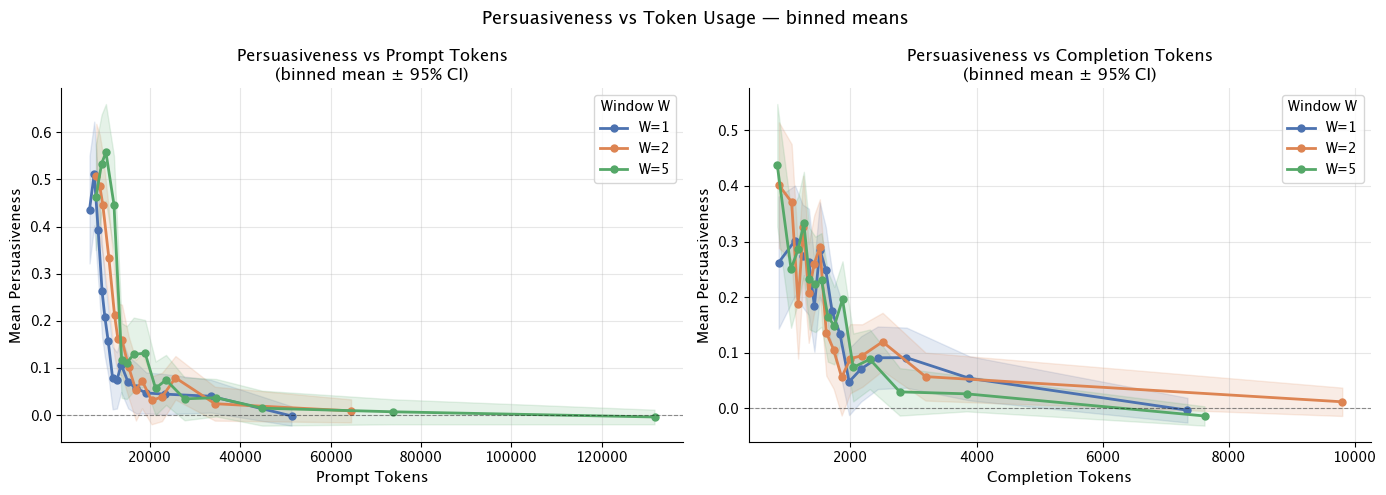

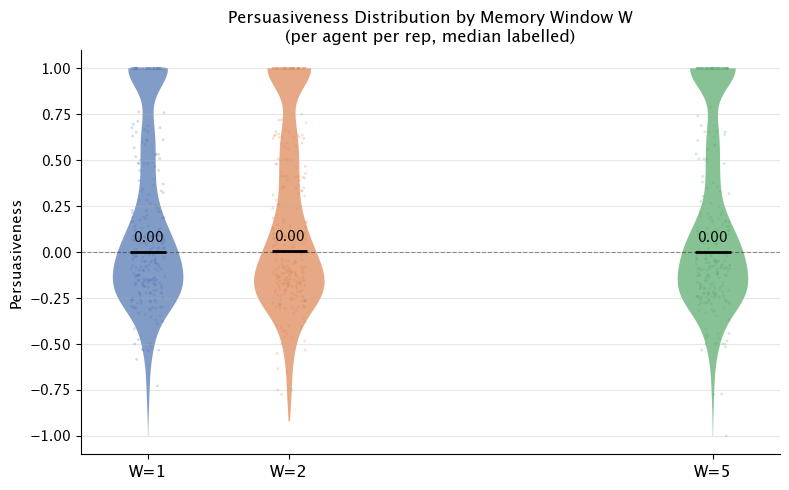

In [54]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for xcol, xlabel, ax in [
    ('prompt_tokens', 'Prompt Tokens', axes[0]),
    ('completion_tokens', 'Completion Tokens', axes[1]),
]:
    for w in W_VALUES:
        sub = pers_common[pers_common['W'] == w].dropna(subset=['persuasiveness'])
        bins = np.percentile(sub[xcol], np.linspace(0, 100, 16))
        bins = np.unique(bins)
        labels = (bins[:-1] + bins[1:]) / 2
        cut = pd.cut(sub[xcol], bins=bins, labels=labels)
        grouped = sub.groupby(cut)['persuasiveness']
        means = grouped.mean()
        sems  = grouped.sem()
        ns    = grouped.count()
        ci    = sems * 1.96
        valid = ns >= 5
        x_vals = means.index.astype(float)[valid]
        ax.plot(x_vals, means[valid], marker='o', markersize=5,
                color=W_COLORS[w], label=f'W={w}', linewidth=2)
        ax.fill_between(x_vals,
                        (means - ci)[valid],
                        (means + ci)[valid],
                        color=W_COLORS[w], alpha=0.15)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Persuasiveness', fontsize=11)
    ax.set_title(f'Persuasiveness vs {xlabel}\n(binned mean ± 95% CI)', fontsize=12)
    ax.legend(title='Window W', fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness vs Token Usage — binned means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
data_by_w = [
    pers_common[(pers_common['W'] == w)]['persuasiveness'].dropna().values
    for w in W_VALUES
]
parts = ax.violinplot(data_by_w, positions=W_VALUES, showmedians=True, showextrema=False)
for pc, w in zip(parts['bodies'], W_VALUES):
    pc.set_facecolor(W_COLORS[w])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

for w, vals in zip(W_VALUES, data_by_w):
    jitter = np.random.uniform(-0.12, 0.12, min(len(vals), 300))
    sample = np.random.choice(vals, size=min(len(vals), 300), replace=False)
    ax.scatter(w + jitter, sample, s=4, alpha=0.25, color=W_COLORS[w], edgecolors='none')
    ax.text(w, np.nanmedian(vals) + 0.04, f'{np.nanmedian(vals):.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xticks(W_VALUES)
ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=12)
ax.set_ylabel('Persuasiveness', fontsize=11)
ax.set_title('Persuasiveness Distribution by Memory Window W\n(per agent per rep, median labelled)',
             fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


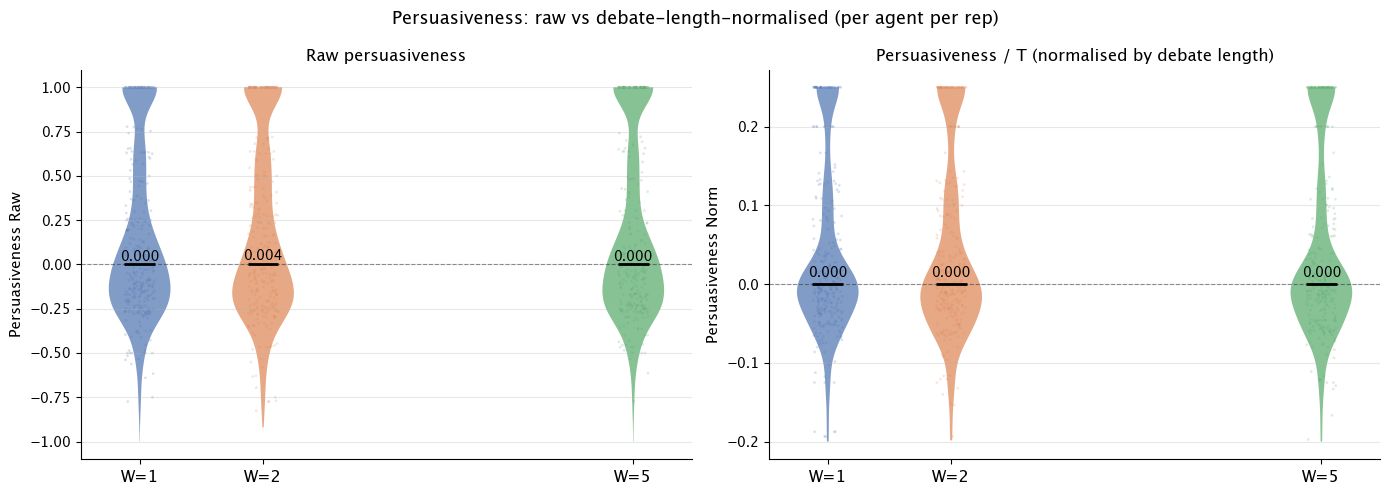

Mean normalised persuasiveness by W:


,mean,median,std
W,,,
1,0.0369,0.0000,0.1079
2,0.0414,0.0004,0.1134
5,0.0422,0.0000,0.1139


In [55]:
pers_norm_records = []
for w, data in raw.items():
    for qid, d in data.items():
        for rep_idx, rep in enumerate(d['repetitions']):
            T = len(rep['trajectory'])
            agent_scores = compute_persuasiveness(rep)
            for a, score in agent_scores.items():
                pers_norm_records.append({
                    'W': w, 'qid': qid,
                    'rep': rep_idx, 'agent': a,
                    'persuasiveness_raw': score,
                    'persuasiveness_norm': score / T if (T > 0 and not np.isnan(score)) else np.nan,
                    'T': T,
                })

pers_norm_df = pd.DataFrame(pers_norm_records)
pers_norm_common = pers_norm_df[pers_norm_df['qid'].isin(common_qids)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'persuasiveness_raw',  'Raw persuasiveness'),
    (axes[1], 'persuasiveness_norm', 'Persuasiveness / T (normalised by debate length)'),
]:
    data_by_w = [
        pers_norm_common[pers_norm_common['W'] == w][col].dropna().values
        for w in W_VALUES
    ]
    parts = ax.violinplot(data_by_w, positions=W_VALUES, showmedians=True, showextrema=False)
    for pc, w in zip(parts['bodies'], W_VALUES):
        pc.set_facecolor(W_COLORS[w])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for w, vals in zip(W_VALUES, data_by_w):
        jitter = np.random.uniform(-0.12, 0.12, min(len(vals), 300))
        sample = np.random.choice(vals, size=min(len(vals), 300), replace=False)
        ax.scatter(w + jitter, sample, s=4, alpha=0.2, color=W_COLORS[w], edgecolors='none')
        ax.text(w, np.nanmedian(vals) + 0.005, f'{np.nanmedian(vals):.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xticks(W_VALUES)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=12)
    ax.set_ylabel(col.replace('_', ' ').title(), fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness: raw vs debate-length-normalised (per agent per rep)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean normalised persuasiveness by W:')
display(
    pers_norm_common.groupby('W')['persuasiveness_norm']
    .agg(['mean', 'median', 'std'])
    .round(4)
)


In [56]:
enriched = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        gt = d['ground_truth']
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            agent_scores = compute_persuasiveness(rep)
            for a in range(N):
                own_confs = [
                    traj[t]['phase_b'][a].get('confidence') or 0
                    for t in range(T)
                ]
                own_flips = sum(
                    1 for t in range(1, T)
                    if traj[t]['phase_b'][a]['vote'] != traj[t-1]['phase_b'][a]['vote']
                )
                v0 = traj[0]['phase_b'][a]['vote']
                vf = traj[-1]['phase_b'][a]['vote']
                votes_r0 = [traj[0]['phase_b'][b]['vote'] for b in range(N)]
                majority_r0 = max(set(votes_r0), key=votes_r0.count)
                n_same_r0 = votes_r0.count(v0)
                n_converts = sum(
                    1 for t in range(T - 1)
                    for b in range(N)
                    if b != a
                    and traj[t]['phase_b'][b]['vote'] != traj[t]['phase_b'][a]['vote']
                    and traj[t+1]['phase_b'][b]['vote'] == traj[t]['phase_b'][a]['vote']
                )
                enriched.append({
                    'W': w, 'qid': qid, 'rep': rep_idx, 'agent': a,
                    'persuasiveness': agent_scores.get(a, np.nan),
                    'T': T,
                    'own_mean_conf': np.mean(own_confs),
                    'own_conf_r0': own_confs[0],
                    'own_conf_delta': own_confs[-1] - own_confs[0],
                    'own_flips': own_flips,
                    'n_converts': n_converts,
                    'in_majority_r0': n_same_r0 > N / 2,
                    'initial_correct': v0 == gt,
                    'final_correct': vf == gt,
                    'consistent': own_flips == 0,
                })

edf = pd.DataFrame(enriched).dropna(subset=['persuasiveness'])
print(f'Enriched rows: {len(edf)}')
display(edf.head(8))


Enriched rows: 6696


,W,qid,rep,agent,persuasiveness,T,own_mean_conf,own_conf_r0,own_conf_delta,own_flips,n_converts,in_majority_r0,initial_correct,final_correct,consistent
0,1,98,0,0,1.000000,4,8.50,7,2,0,1,True,False,False,True
1,1,98,0,1,1.000000,4,8.50,7,3,0,1,True,False,False,True
2,1,98,0,2,1.000000,4,7.50,5,4,0,1,True,False,False,True
3,1,98,0,3,-0.296296,4,8.75,8,1,1,0,False,False,False,False
4,1,98,1,0,1.000000,4,8.25,7,2,0,2,False,False,False,True
5,1,98,1,1,1.000000,4,8.00,7,2,0,2,False,False,False,True
6,1,98,1,2,0.000000,4,0.75,0,2,1,0,False,False,False,False
7,1,98,1,3,-0.333333,4,8.50,7,3,1,0,False,False,False,False


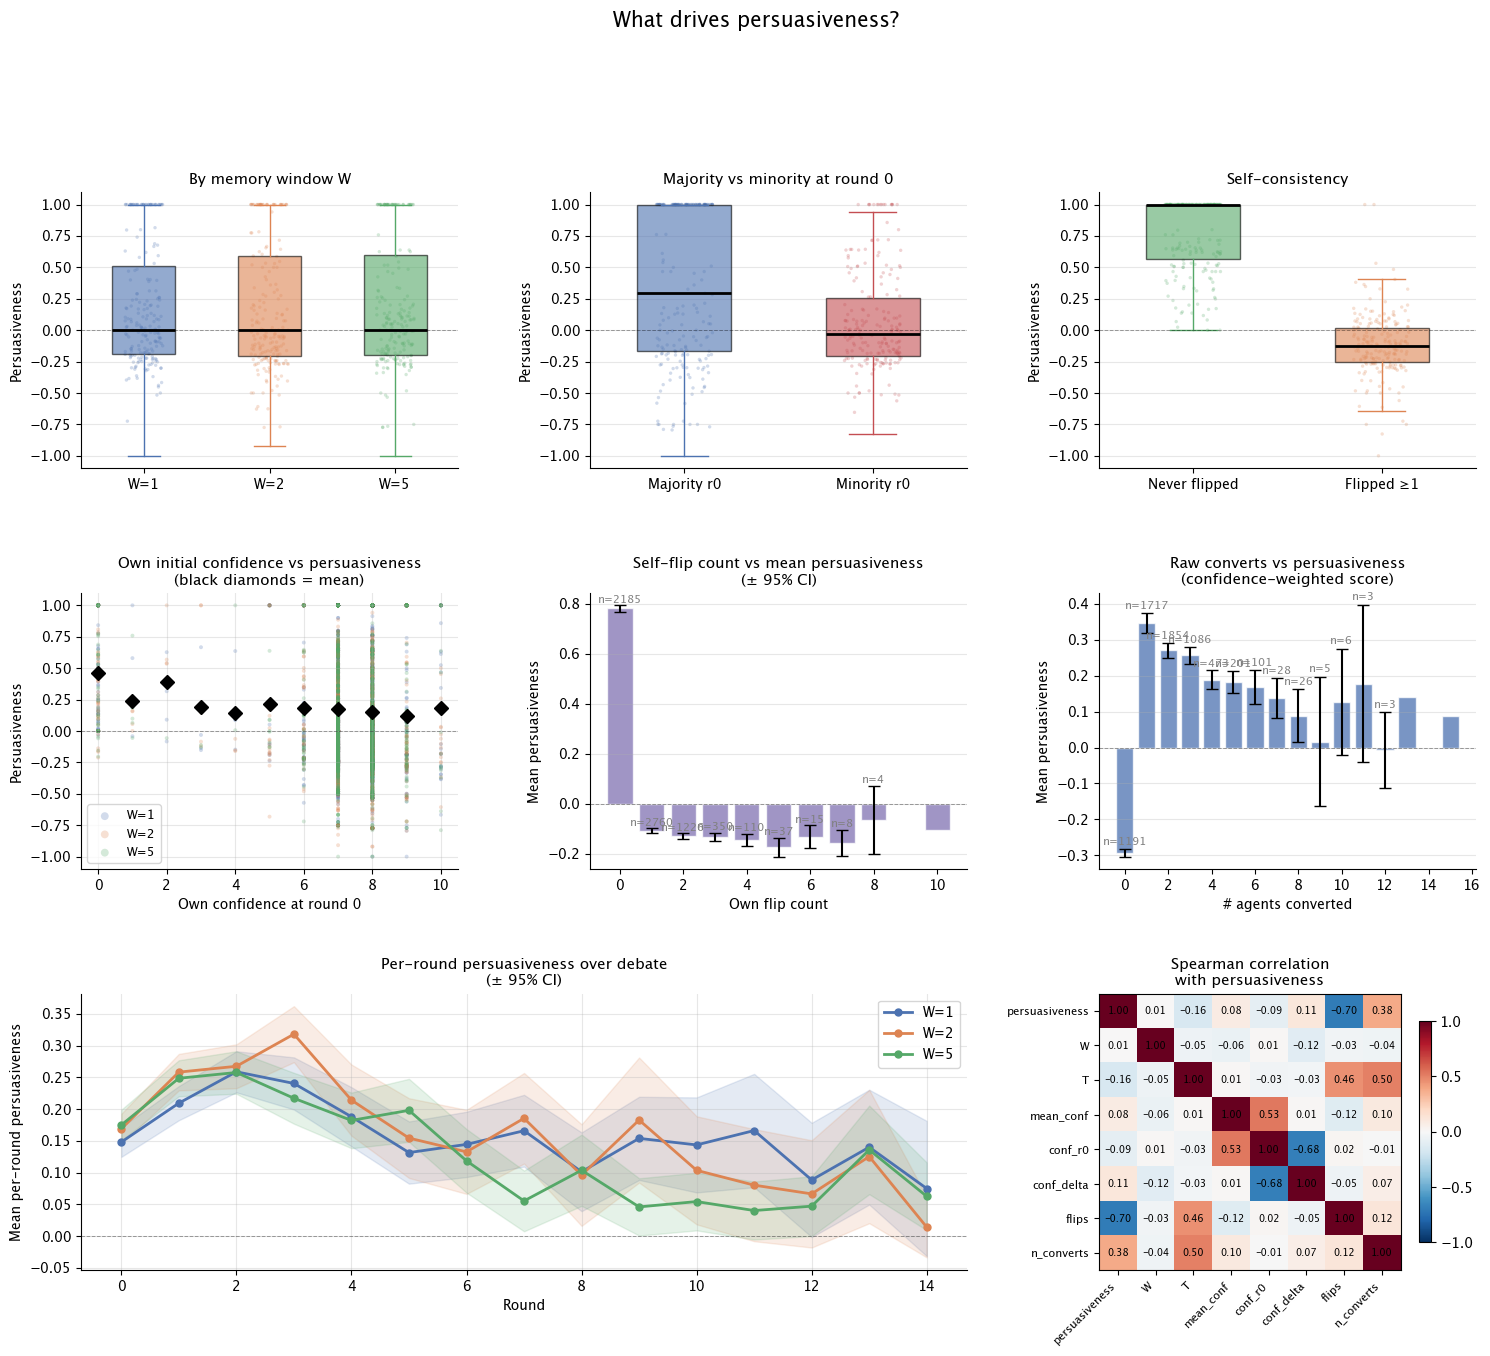

In [57]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def jitter_box(ax, groups, labels, colors, ylabel, title):
    for i, (vals, color) in enumerate(zip(groups, colors)):
        bp = ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(facecolor=color, alpha=0.6),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color),
                        flierprops=dict(marker='', alpha=0))
        jitter = np.random.uniform(-0.15, 0.15, min(len(vals), 200))
        sample = np.random.choice(vals, size=min(len(vals), 200), replace=False)
        ax.scatter(i + jitter, sample, s=6, alpha=0.25, color=color, edgecolors='none')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 1. Persuasiveness by W
ax = fig.add_subplot(gs[0, 0])
jitter_box(ax,
    [edf[edf['W']==w]['persuasiveness'].values for w in W_VALUES],
    [f'W={w}' for w in W_VALUES],
    [W_COLORS[w] for w in W_VALUES],
    'Persuasiveness', 'By memory window W')

# 2. Majority vs minority at round 0
ax = fig.add_subplot(gs[0, 1])
jitter_box(ax,
    [edf[edf['in_majority_r0']==v]['persuasiveness'].values for v in [True, False]],
    ['Majority r0', 'Minority r0'],
    ['#4C72B0', '#C44E52'],
    'Persuasiveness', 'Majority vs minority at round 0')

# 3. Consistent (never flipped) vs flipped
ax = fig.add_subplot(gs[0, 2])
jitter_box(ax,
    [edf[edf['consistent']==v]['persuasiveness'].values for v in [True, False]],
    ['Never flipped', 'Flipped ≥1'],
    ['#55A868', '#DD8452'],
    'Persuasiveness', 'Self-consistency')

# 4. Own confidence r0 vs persuasiveness scatter
ax = fig.add_subplot(gs[1, 0])
for w in W_VALUES:
    sub = edf[edf['W'] == w]
    ax.scatter(sub['own_conf_r0'], sub['persuasiveness'],
               color=W_COLORS[w], s=8, alpha=0.25, edgecolors='none', label=f'W={w}')
for conf_val in edf['own_conf_r0'].unique():
    m = edf[edf['own_conf_r0'] == conf_val]['persuasiveness'].mean()
    ax.plot(conf_val, m, 'kD', markersize=7, zorder=5)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.35)
ax.set_xlabel('Own confidence at round 0', fontsize=10)
ax.set_ylabel('Persuasiveness', fontsize=10)
ax.set_title('Own initial confidence vs persuasiveness\n(black diamonds = mean)', fontsize=11)
ax.legend(fontsize=9, markerscale=2)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Own flip count vs persuasiveness
ax = fig.add_subplot(gs[1, 1])
flip_means = edf.groupby('own_flips')['persuasiveness'].mean()
flip_sems  = edf.groupby('own_flips')['persuasiveness'].sem()
flip_ns    = edf.groupby('own_flips')['persuasiveness'].count()
ax.bar(flip_means.index, flip_means.values,
       color='#8172B2', alpha=0.75, edgecolor='white')
ax.errorbar(flip_means.index, flip_means.values, yerr=flip_sems.values * 1.96,
            fmt='none', color='black', capsize=4, linewidth=1.5)
for x, n in flip_ns.items():
    ax.text(x, flip_means[x] + flip_sems[x]*2 + 0.01, f'n={n}',
            ha='center', fontsize=8, color='gray')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.35)
ax.set_xlabel('Own flip count', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Self-flip count vs mean persuasiveness\n(± 95% CI)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. n_converts vs persuasiveness
ax = fig.add_subplot(gs[1, 2])
conv_means = edf.groupby('n_converts')['persuasiveness'].mean()
conv_sems  = edf.groupby('n_converts')['persuasiveness'].sem()
conv_ns    = edf.groupby('n_converts')['persuasiveness'].count()
ax.bar(conv_means.index, conv_means.values,
       color='#4C72B0', alpha=0.75, edgecolor='white')
ax.errorbar(conv_means.index, conv_means.values, yerr=conv_sems.values * 1.96,
            fmt='none', color='black', capsize=4, linewidth=1.5)
for x, n in conv_ns.items():
    ax.text(x, conv_means[x] + conv_sems[x]*2 + 0.01, f'n={n}',
            ha='center', fontsize=8, color='gray')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.35)
ax.set_xlabel('# agents converted', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Raw converts vs persuasiveness\n(confidence-weighted score)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 7. Per-round persuasiveness trajectory
ax = fig.add_subplot(gs[2, 0:2])
round_records = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        gt = d['ground_truth']
        for rep in d['repetitions']:
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            for t in range(T - 1):
                phase     = traj[t]['phase_b']
                next_phase = traj[t+1]['phase_b']
                for a in range(N):
                    v_a = phase[a]['vote']
                    c_a = phase[a].get('confidence') or 0
                    k   = sum(1 for ag in range(N) if phase[ag]['vote'] == v_a)
                    num = denom = 0.0
                    for b in range(N):
                        if b == a:
                            continue
                        v_b = phase[b]['vote']
                        v_b_next = next_phase[b]['vote']
                        c_b = phase[b].get('confidence') or 0
                        if v_b != v_a:
                            denom += c_b / k
                            if v_b_next == v_a:
                                num += c_b / k
                    if next_phase[a]['vote'] != v_a:
                        num   -= c_a
                        denom += c_a
                    round_records.append({
                        'W': w, 'round': t,
                        'pers_round': num / denom if denom > 0 else np.nan,
                    })

rdf = pd.DataFrame(round_records).dropna()
for w in W_VALUES:
    sub = rdf[rdf['W'] == w].groupby('round')['pers_round']
    means = sub.mean()
    sems  = sub.sem()
    ax.plot(means.index, means.values, marker='o', color=W_COLORS[w],
            label=f'W={w}', linewidth=2, markersize=5)
    ax.fill_between(means.index,
                    means - sems * 1.96,
                    means + sems * 1.96,
                    color=W_COLORS[w], alpha=0.15)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.35)
ax.set_xlabel('Round', fontsize=10)
ax.set_ylabel('Mean per-round persuasiveness', fontsize=10)
ax.set_title('Per-round persuasiveness over debate\n(± 95% CI)', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 8. Correlation heatmap
ax = fig.add_subplot(gs[2, 2])
corr_cols = ['persuasiveness', 'W', 'T', 'own_mean_conf', 'own_conf_r0',
             'own_conf_delta', 'own_flips', 'n_converts']
corr = edf[corr_cols].corr(method='spearman')
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels([c.replace('own_', '') for c in corr_cols],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels([c.replace('own_', '') for c in corr_cols], fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')
ax.set_title('Spearman correlation\nwith persuasiveness', fontsize=11)

fig.suptitle('What drives persuasiveness?', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('../plots/persuasiveness_drivers.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
# Build exogenous features — all computable at/before round 0
exog = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        gt = d['ground_truth']
        q_acc = dc[(dc['qid'] == qid) & (dc['W'] == w)]['accuracy'].values
        q_accuracy = q_acc[0] if len(q_acc) else np.nan
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            r0 = traj[0]['phase_b']
            votes_r0  = [a['vote'] for a in r0]
            confs_r0  = [a.get('confidence') or 0 for a in r0]
            vote_counts = {v: votes_r0.count(v) for v in set(votes_r0)}
            majority_count = max(vote_counts.values())
            # vote split label: '4-0', '3-1', '2-2'
            counts_sorted = tuple(sorted(vote_counts.values(), reverse=True))
            split_label = '-'.join(map(str, counts_sorted))
            agent_scores = compute_persuasiveness(rep)
            for a in range(N):
                own_conf_r0   = confs_r0[a]
                others_conf   = [confs_r0[b] for b in range(N) if b != a]
                conf_advantage = own_conf_r0 - np.mean(others_conf)
                in_majority   = votes_r0.count(votes_r0[a]) == majority_count
                exog.append({
                    'W':              w,
                    'qid':            qid,
                    'rep':            rep_idx,
                    'agent':          a,
                    'persuasiveness': agent_scores.get(a, np.nan),
                    'q_accuracy':     q_accuracy,
                    'split_label':    split_label,
                    'n_unique_votes': len(vote_counts),
                    'conf_advantage': conf_advantage,
                    'group_conf_mean': np.mean(confs_r0),
                    'group_conf_std':  np.std(confs_r0),
                    'in_majority_r0': in_majority,
                    'own_conf_r0':    own_conf_r0,
                })

exog_df = pd.DataFrame(exog).dropna(subset=['persuasiveness'])
print(f'Exogenous feature rows: {len(exog_df)}')
display(exog_df.head(6))


Exogenous feature rows: 6696


,W,qid,rep,agent,persuasiveness,q_accuracy,split_label,n_unique_votes,conf_advantage,group_conf_mean,group_conf_std,in_majority_r0,own_conf_r0
0,1,98,0,0,1.000000,0.28,3-1,2,0.333333,6.75,1.089725,True,7
1,1,98,0,1,1.000000,0.28,3-1,2,0.333333,6.75,1.089725,True,7
2,1,98,0,2,1.000000,0.28,3-1,2,-2.333333,6.75,1.089725,True,5
3,1,98,0,3,-0.296296,0.28,3-1,2,1.666667,6.75,1.089725,False,8
4,1,98,1,0,1.000000,0.28,2-1-1,3,2.333333,5.25,3.031089,True,7
5,1,98,1,1,1.000000,0.28,2-1-1,3,2.333333,5.25,3.031089,True,7


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/2933513045.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['persuasiveness']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/2933513045.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['persuasiveness']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/2933513045.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt th

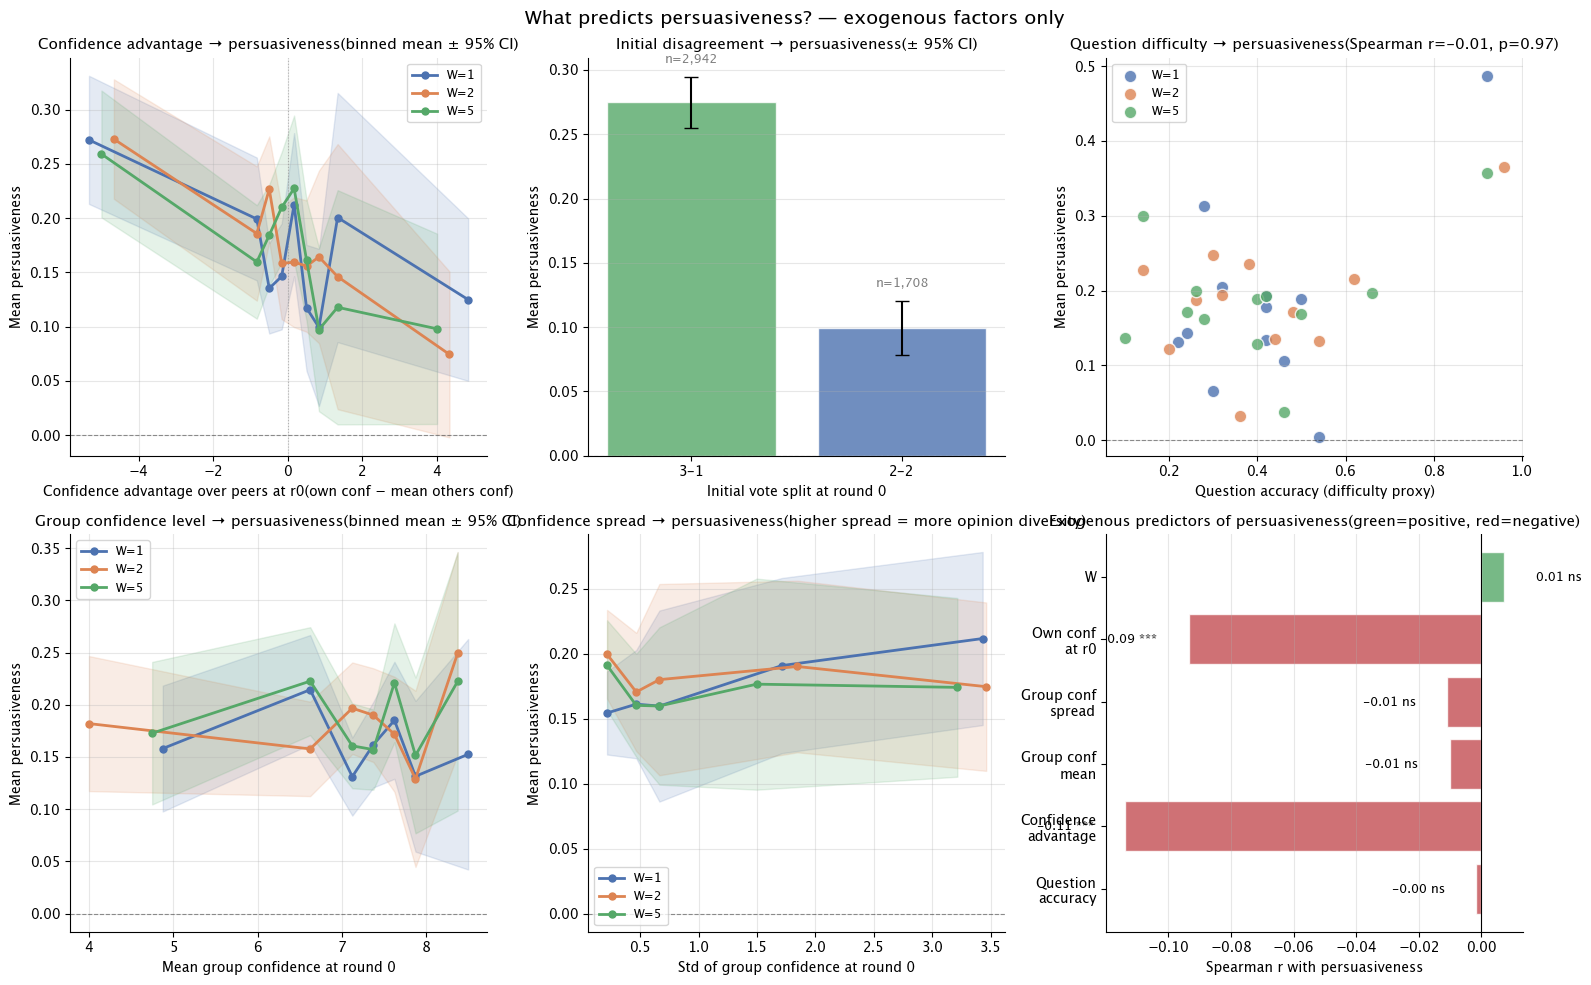

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

# 1. Confidence advantage vs persuasiveness (binned mean)
ax = axes[0]
for w in W_VALUES:
    sub = exog_df[exog_df['W'] == w]
    bins = np.percentile(sub['conf_advantage'], np.linspace(0, 100, 12))
    bins = np.unique(bins)
    labels = (bins[:-1] + bins[1:]) / 2
    cut = pd.cut(sub['conf_advantage'], bins=bins, labels=labels)
    grp = sub.groupby(cut)['persuasiveness']
    means, sems = grp.mean(), grp.sem()
    ns = grp.count()
    valid = ns >= 5
    x = means.index.astype(float)[valid]
    ax.plot(x, means[valid], marker='o', markersize=5,
            color=W_COLORS[w], label=f'W={w}', linewidth=2)
    ax.fill_between(x, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                    color=W_COLORS[w], alpha=0.15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Confidence advantage over peers at r0(own conf − mean others conf)', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Confidence advantage → persuasiveness(binned mean ± 95% CI)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 2. Initial vote split vs persuasiveness
ax = axes[1]
split_order = ['4-0', '3-1', '2-2']
split_order = [s for s in split_order if s in exog_df['split_label'].values]
split_means = exog_df.groupby('split_label')['persuasiveness'].mean().reindex(split_order)
split_sems  = exog_df.groupby('split_label')['persuasiveness'].sem().reindex(split_order)
split_ns    = exog_df.groupby('split_label')['persuasiveness'].count().reindex(split_order)
colors_split = ['#55A868', '#4C72B0', '#C44E52']
bars = ax.bar(split_order, split_means.values,
              color=colors_split[:len(split_order)], alpha=0.8, edgecolor='white')
ax.errorbar(range(len(split_order)), split_means.values, yerr=split_sems.values*1.96,
            fmt='none', color='black', capsize=5, linewidth=1.5)
for i, (v, n) in enumerate(zip(split_means.values, split_ns.values)):
    ax.text(i, v + split_sems.values[i]*2 + 0.01, f'n={n:,}',
            ha='center', fontsize=9, color='gray')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Initial vote split at round 0', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Initial disagreement → persuasiveness(± 95% CI)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 3. Question difficulty (accuracy) vs persuasiveness
ax = axes[2]
for w in W_VALUES:
    sub = exog_df[exog_df['W'] == w]
    q_means = sub.groupby('qid').agg(
        persuasiveness=('persuasiveness', 'mean'),
        q_accuracy=('q_accuracy', 'first')
    ).reset_index()
    ax.scatter(q_means['q_accuracy'], q_means['persuasiveness'],
               color=W_COLORS[w], label=f'W={w}', s=80, alpha=0.8, edgecolors='white')
all_q = exog_df.groupby('qid').agg(
    persuasiveness=('persuasiveness', 'mean'),
    q_accuracy=('q_accuracy', 'first')
)
r, p = sp_stats.spearmanr(all_q['q_accuracy'], all_q['persuasiveness'])
ax.set_xlabel('Question accuracy (difficulty proxy)', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title(f'Question difficulty → persuasiveness(Spearman r={r:.2f}, p={p:.2f})', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 4. Group confidence mean at r0 vs persuasiveness (binned)
ax = axes[3]
for w in W_VALUES:
    sub = exog_df[exog_df['W'] == w]
    bins = np.percentile(sub['group_conf_mean'], np.linspace(0, 100, 10))
    bins = np.unique(bins)
    if len(bins) < 3:
        continue
    labels = (bins[:-1] + bins[1:]) / 2
    cut = pd.cut(sub['group_conf_mean'], bins=bins, labels=labels)
    grp = sub.groupby(cut)['persuasiveness']
    means, sems = grp.mean(), grp.sem()
    ns = grp.count()
    valid = ns >= 5
    x = means.index.astype(float)[valid]
    ax.plot(x, means[valid], marker='o', markersize=5,
            color=W_COLORS[w], label=f'W={w}', linewidth=2)
    ax.fill_between(x, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                    color=W_COLORS[w], alpha=0.15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Mean group confidence at round 0', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Group confidence level → persuasiveness(binned mean ± 95% CI)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 5. Group confidence spread at r0 vs persuasiveness (binned)
ax = axes[4]
for w in W_VALUES:
    sub = exog_df[exog_df['W'] == w]
    bins = np.percentile(sub['group_conf_std'], np.linspace(0, 100, 10))
    bins = np.unique(bins)
    if len(bins) < 3:
        continue
    labels = (bins[:-1] + bins[1:]) / 2
    cut = pd.cut(sub['group_conf_std'], bins=bins, labels=labels)
    grp = sub.groupby(cut)['persuasiveness']
    means, sems = grp.mean(), grp.sem()
    ns = grp.count()
    valid = ns >= 5
    x = means.index.astype(float)[valid]
    ax.plot(x, means[valid], marker='o', markersize=5,
            color=W_COLORS[w], label=f'W={w}', linewidth=2)
    ax.fill_between(x, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                    color=W_COLORS[w], alpha=0.15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Std of group confidence at round 0', fontsize=10)
ax.set_ylabel('Mean persuasiveness', fontsize=10)
ax.set_title('Confidence spread → persuasiveness(higher spread = more opinion diversity)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 6. Spearman correlations with persuasiveness — only exogenous factors
ax = axes[5]
exog_corr_cols = ['q_accuracy', 'conf_advantage', 'group_conf_mean',
                  'group_conf_std', 'own_conf_r0', 'W']
corr_vals = [sp_stats.spearmanr(
                 exog_df[c], exog_df['persuasiveness']
             ) for c in exog_corr_cols]
rs   = [r for r, p in corr_vals]
ps   = [p for r, p in corr_vals]
labels_c = ['Question\naccuracy', 'Confidence\nadvantage', 'Group conf\nmean',
            'Group conf\nspread', 'Own conf\nat r0', 'W']
colors_c = ['#C44E52' if r < 0 else '#55A868' for r in rs]
bars = ax.barh(range(len(rs)), rs, color=colors_c, alpha=0.8, edgecolor='white')
for i, (r, p) in enumerate(zip(rs, ps)):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.text(r + (0.01 if r >= 0 else -0.01), i,
            f'{r:.2f} {sig}', va='center',
            ha='left' if r >= 0 else 'right', fontsize=9)
ax.set_yticks(range(len(labels_c)))
ax.set_yticklabels(labels_c, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman r with persuasiveness', fontsize=10)
ax.set_title('Exogenous predictors of persuasiveness(green=positive, red=negative)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('What predicts persuasiveness? — exogenous factors only',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/persuasiveness_exogenous.png', dpi=150, bbox_inches='tight')
plt.show()


## Message Alignment

In [61]:
import re, string
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

STOPWORDS = {
    'the','a','an','is','it','in','of','to','and','or','that','this',
    'for','with','are','was','be','as','by','at','from','on','have',
    'has','its','we','i','you','they','their','our','which','but','not',
    'if','so','can','will','would','could','should','may','also','more',
    'than','each','other','all','any','one','two','there','these','those',
}

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    return tokens

def bigram_jaccard(msg_a, msg_b):
    ta, tb = preprocess(msg_a), preprocess(msg_b)
    bg_a = set(zip(ta, ta[1:]))
    bg_b = set(zip(tb, tb[1:]))
    if not bg_a and not bg_b:
        return 1.0
    if not bg_a or not bg_b:
        return 0.0
    return len(bg_a & bg_b) / len(bg_a | bg_b)

def mean_pairwise(msgs, fn):
    pairs = list(combinations(range(len(msgs)), 2))
    if not pairs:
        return np.nan
    return np.mean([fn(msgs[i], msgs[j]) for i, j in pairs])

# collect all messages to fit global TF-IDF
all_msgs = []
for w, data in raw.items():
    for qid, d in data.items():
        for rep in d['repetitions']:
            for rnd in rep['trajectory']:
                for ag in rnd['phase_b']:
                    m = ag.get('message', '')
                    if m:
                        all_msgs.append(m)

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=8000,
                        stop_words=list(STOPWORDS))
tfidf.fit(all_msgs)

def tfidf_cosine(msgs):
    if len(msgs) < 2:
        return np.nan
    vecs = tfidf.transform(msgs).toarray()
    pairs = list(combinations(range(len(vecs)), 2))
    sims = [cosine_similarity(vecs[i].reshape(1,-1), vecs[j].reshape(1,-1))[0,0]
            for i,j in pairs]
    return np.mean(sims)

align_records = []
for w, data in raw.items():
    for qid, d in data.items():
        gt = d['ground_truth']
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            T = len(traj)
            for t, rnd in enumerate(traj):
                msgs = [ag.get('message','') for ag in rnd['phase_b']]
                msgs = [m for m in msgs if m]
                votes = [ag['vote'] for ag in rnd['phase_b']]
                majority = max(set(votes), key=votes.count)
                align_records.append({
                    'W':          w,
                    'qid':        qid,
                    'dataset':    d.get('dataset','unknown'),
                    'rep':        rep_idx,
                    'round':      t,
                    'T':          T,
                    'tfidf_cos':  tfidf_cosine(msgs),
                    'bigram_jac': mean_pairwise(msgs, bigram_jaccard),
                    'vote_agree': max(votes.count(v) for v in set(votes)) / len(votes),
                    'correct':    majority == gt,
                })

adf = pd.DataFrame(align_records)
adf_common = adf[adf['qid'].isin(common_qids)]

print(f'Alignment rows (common qids): {len(adf_common)}')
print()
print('Mean alignment by W:')
display(adf_common.groupby('W')[['tfidf_cos','bigram_jac','vote_agree']].mean().round(3))


Alignment rows (common qids): 11049

Mean alignment by W:


,tfidf_cos,bigram_jac,vote_agree
W,,,
1,0.425,0.221,0.807
2,0.413,0.207,0.826
5,0.406,0.199,0.816


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/1175369117.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = adf_common.groupby(cut)[col]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_18739/1175369117.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = adf_common.groupby(cut)[col]


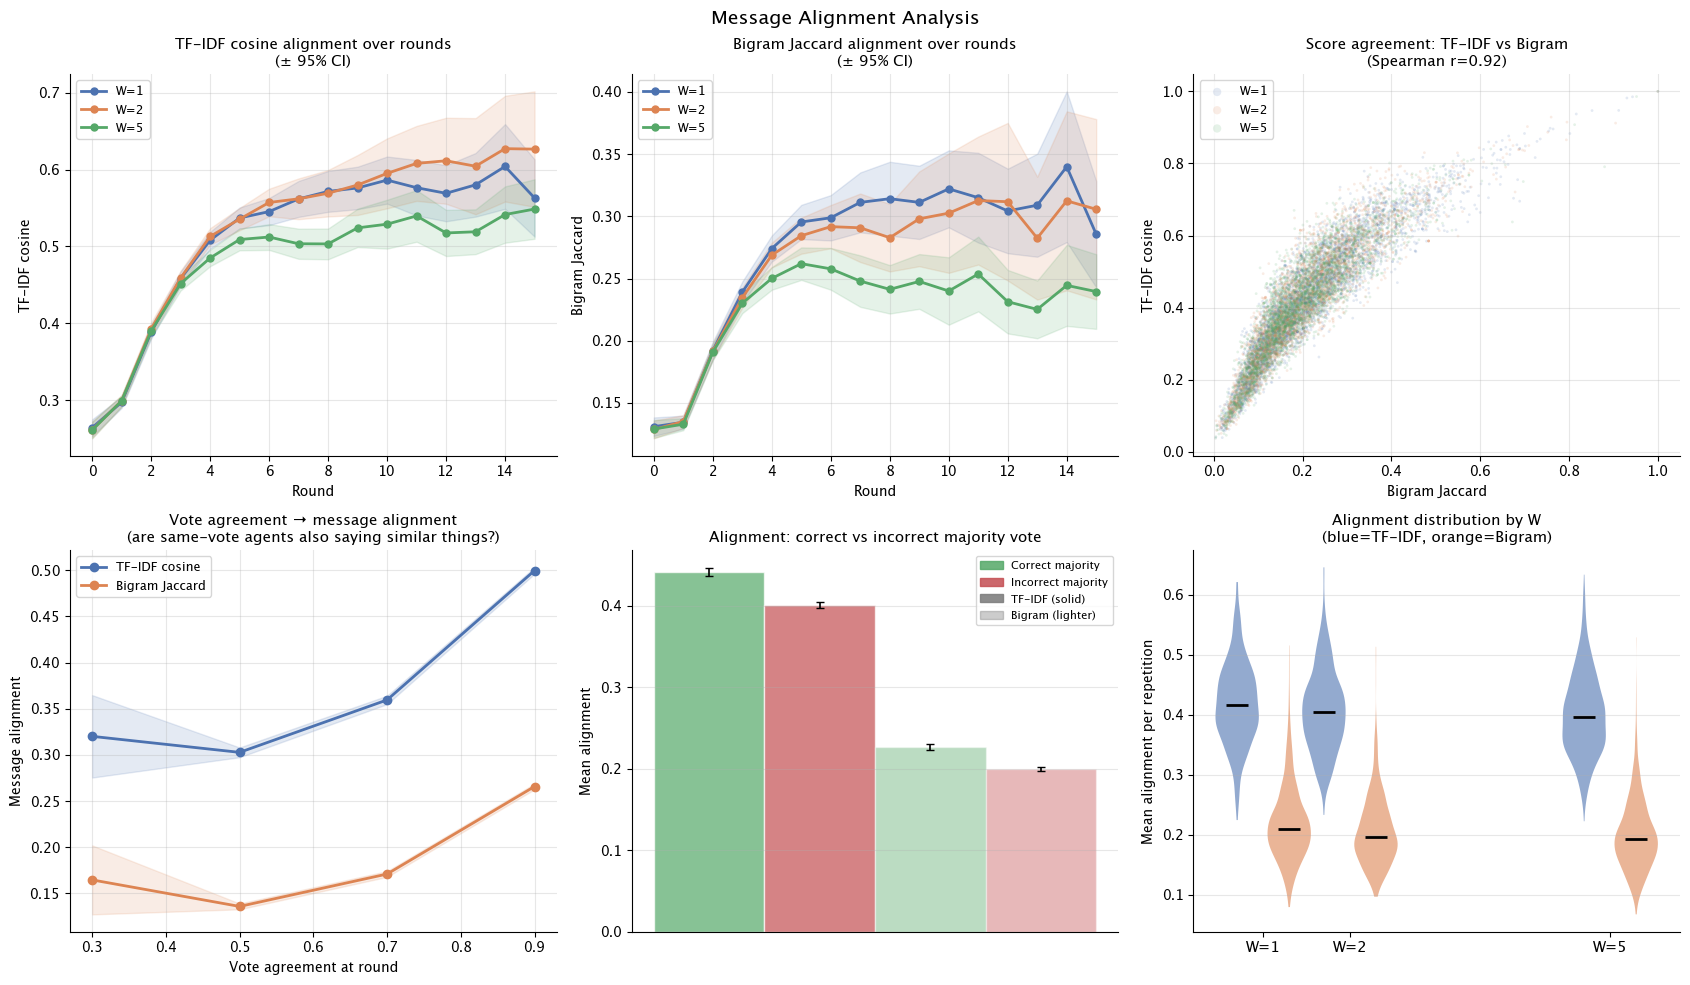

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 1 & 2: Alignment trajectories over rounds
for ax, col, label in [
    (axes[0,0], 'tfidf_cos',  'TF-IDF cosine'),
    (axes[0,1], 'bigram_jac', 'Bigram Jaccard'),
]:
    for w in W_VALUES:
        sub = adf_common[adf_common['W'] == w].groupby('round')[col]
        means, sems = sub.mean(), sub.sem()
        ax.plot(means.index, means.values, marker='o', markersize=5,
                color=W_COLORS[w], label=f'W={w}', linewidth=2)
        ax.fill_between(means.index, means-sems*1.96, means+sems*1.96,
                        color=W_COLORS[w], alpha=0.15)
    ax.set_xlabel('Round', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} alignment over rounds\n(± 95% CI)', fontsize=11)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 3: TF-IDF vs Bigram Jaccard scatter (are they correlated?)
ax = axes[0,2]
for w in W_VALUES:
    sub = adf_common[adf_common['W'] == w]
    ax.scatter(sub['bigram_jac'], sub['tfidf_cos'],
               color=W_COLORS[w], s=4, alpha=0.15, edgecolors='none', label=f'W={w}')
r_ab, _ = sp_stats.spearmanr(adf_common['bigram_jac'].dropna(),
                               adf_common['tfidf_cos'].dropna())
ax.set_xlabel('Bigram Jaccard', fontsize=10)
ax.set_ylabel('TF-IDF cosine', fontsize=10)
ax.set_title(f'Score agreement: TF-IDF vs Bigram\n(Spearman r={r_ab:.2f})', fontsize=11)
ax.legend(fontsize=9, markerscale=3)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 4: Message alignment vs vote agreement
ax = axes[1,0]
for col, color, label in [('tfidf_cos','#4C72B0','TF-IDF cosine'),
                            ('bigram_jac','#DD8452','Bigram Jaccard')]:
    bins = np.linspace(0, 1, 6)
    labels_b = (bins[:-1] + bins[1:]) / 2
    cut = pd.cut(adf_common['vote_agree'], bins=bins, labels=labels_b)
    grp = adf_common.groupby(cut)[col]
    means, sems = grp.mean(), grp.sem()
    ax.plot(means.index.astype(float), means.values, marker='o', markersize=6,
            color=color, label=label, linewidth=2)
    ax.fill_between(means.index.astype(float), means-sems*1.96, means+sems*1.96,
                    color=color, alpha=0.15)
ax.set_xlabel('Vote agreement at round', fontsize=10)
ax.set_ylabel('Message alignment', fontsize=10)
ax.set_title('Vote agreement → message alignment\n(are same-vote agents also saying similar things?)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 5: Alignment by correct/incorrect majority
ax = axes[1,1]
x = np.arange(2)
w_bar = 0.13
for i, (col, label) in enumerate([('tfidf_cos','TF-IDF'), ('bigram_jac','Bigram Jac')]):
    for j, (correct, clabel) in enumerate([(True,'Correct'),(False,'Incorrect')]):
        sub = adf_common[adf_common['correct'] == correct][col]
        offset = (i * 2 + j - 1.5) * w_bar
        bar = ax.bar(offset, sub.mean(), w_bar,
                     color='#55A868' if correct else '#C44E52',
                     alpha=0.7 if i==0 else 0.4,
                     edgecolor='white',
                     label=f'{label} – {clabel}' if True else '')
        ax.errorbar(offset, sub.mean(), yerr=sub.sem()*1.96,
                    fmt='none', color='black', capsize=3, linewidth=1.2)
ax.set_xticks([])
handles = [
    plt.Rectangle((0,0),1,1, color='#55A868', alpha=0.85),
    plt.Rectangle((0,0),1,1, color='#C44E52', alpha=0.85),
    plt.Rectangle((0,0),1,1, color='gray', alpha=0.9),
    plt.Rectangle((0,0),1,1, color='gray', alpha=0.4),
]
ax.legend(handles, ['Correct majority','Incorrect majority','TF-IDF (solid)','Bigram (lighter)'],
          fontsize=8)
ax.set_ylabel('Mean alignment', fontsize=10)
ax.set_title('Alignment: correct vs incorrect majority vote', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 6: Violin of per-rep mean alignment by W
ax = axes[1,2]
rep_align = adf_common.groupby(['W','qid','rep'])[['tfidf_cos','bigram_jac']].mean().reset_index()
positions_tfidf = [w - 0.3 for w in W_VALUES]
positions_bjac  = [w + 0.3 for w in W_VALUES]
for positions, col, color, label in [
    (positions_tfidf, 'tfidf_cos',  '#4C72B0', 'TF-IDF cosine'),
    (positions_bjac,  'bigram_jac', '#DD8452', 'Bigram Jaccard'),
]:
    data_w = [rep_align[rep_align['W']==w][col].dropna().values for w in W_VALUES]
    parts = ax.violinplot(data_w, positions=positions, widths=0.5,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

ax.set_xticks(W_VALUES)
ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=11)
ax.set_ylabel('Mean alignment per repetition', fontsize=10)
ax.set_title('Alignment distribution by W\n(blue=TF-IDF, orange=Bigram)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Message Alignment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/message_alignment.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary Table

In [19]:
final_table = summary[[
    'accuracy', 'initial_acc', 'acc_delta',
    'mean_T', 'mean_flips', 'convergence_rate', 'never_converged_rate',
    'mean_conf_0', 'mean_conf_f',
    'mean_prompt_tokens', 'mean_completion_tokens', 'mean_total_tokens',
]].rename(columns={
    'accuracy':               'final_acc',
    'initial_acc':            'init_acc',
    'acc_delta':              'acc_Δ',
    'mean_T':                 'mean_rounds',
    'convergence_rate':       'conv_rate',
    'never_converged_rate':   'no_conv_rate',
    'mean_conf_0':            'conf_r0',
    'mean_conf_f':            'conf_final',
    'mean_prompt_tokens':     'pt_tokens',
    'mean_completion_tokens': 'ct_tokens',
    'mean_total_tokens':      'total_tokens',
})

print('Summary — common questions, fair W comparison:')
display(final_table)

Summary — common questions, fair W comparison:


,final_acc,init_acc,acc_Δ,mean_rounds,mean_flips,conv_rate,no_conv_rate,conf_r0,conf_final,pt_tokens,ct_tokens,total_tokens
W,,,,,,,,,,,,
1,0.420,0.256,0.167,6.413,4.245,0.968,0.0,7.222,9.071,62828.730,8147.605,70976.335
2,0.417,0.267,0.153,5.805,3.632,0.985,0.0,7.200,8.981,73533.263,7472.493,81005.757
5,0.398,0.242,0.159,6.197,3.915,0.962,0.0,7.244,8.865,112980.312,7975.468,120955.780
